# Changellenge Cup IT 2026  |  МТС True Tech — ВЫШЕ КРЫШИ
## Команда: «Пока без названия»

## Подготовка и импорты

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Стиль
plt.rcParams.update({
    'figure.facecolor':  '#0A0A0A',
    'axes.facecolor':    '#14141E',
    'axes.edgecolor':    '#333344',
    'axes.labelcolor':   '#AAAABB',
    'xtick.color':       '#666677',
    'ytick.color':       '#666677',
    'text.color':        '#EEEEEE',
    'grid.color':        '#222233',
    'grid.linewidth':    0.6,
    'figure.dpi':        130,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
})

# Цвета
RED   = '#FF1A2E'
RED2  = '#E30611'
WHITE = '#FFFFFF'
GREY  = '#AAAABB'
CARD  = '#14141E'

# Градиент
MTS_CMAP = LinearSegmentedColormap.from_list('mts', ['#0A0A0A', '#FF1A2E', '#FFFFFF'])
MTS_CMAP2 = LinearSegmentedColormap.from_list('mts2', ['#14141E', '#FF1A2E'])

---
# Раздел 1. Загрузка данных

Загружаем оба датасета и сразу смотрим на их размер и состав

In [2]:
# Пути
PATH_MERGED = 'merged_dataset.csv'   # до ML
PATH_FILLED = 'filled_dataset.csv'   # после ML

merged = pd.read_csv(PATH_MERGED, low_memory=False)

filled = pd.read_csv(PATH_FILLED, low_memory=False)

# Числовые типы
num_cols = ['final_height_m', 'area_sq_m', 'feat_distance_to_center_km',
            'match_iou', 'B_stairs', 'B_height', 'B_avg_floor_height',
            'gkh_floor_count_min', 'gkh_floor_count_max',
            'feat_x_coord', 'feat_y_coord']
for df_ in [merged, filled]:
    for col in num_cols:
        if col in df_.columns:
            df_[col] = pd.to_numeric(df_[col], errors='coerce')

print(f'  merged_dataset:  {merged.shape[0]:>8,} строк  |  {merged.shape[1]} столбцов')
print(f'  filled_dataset:  {filled.shape[0]:>8,} строк  |  {filled.shape[1]} столбцов')

  merged_dataset:   155,439 строк  |  69 столбцов
  filled_dataset:   155,439 строк  |  69 столбцов


---
# Раздел 2. Качество данных

Смотрим на пропуски, источники высоты и качество сопоставления источников А и Б

In [3]:
# Полнота высоты: до и после ML
def height_completeness(df_, name):
    total = len(df_)
    has_h = df_['final_height_m'].notna().sum() if 'final_height_m' in df_.columns else 0
    return {'датасет': name, 'всего': total,
            'с высотой': has_h, 'полнота': has_h/total*100}

comp = pd.DataFrame([height_completeness(merged, 'merged (до ML)'),
                     height_completeness(filled, 'filled (после ML)')])

print('ПОЛНОТА ДАННЫХ О ВЫСОТЕ')
print('─'*55)
for _, row in comp.iterrows():
    bar = '█' * int(row['полнота'] / 2) + '░' * (50 - int(row['полнота'] / 2))
    name  = row['датасет']
    pct   = row['полнота']
    has_h = row['с высотой']
    total = row['всего']
    bar = '\u2588' * int(pct / 2) + '\u2591' * (50 - int(pct / 2))
    print(f'  {name:<22} {pct:5.1f}%  {bar[:30]}')
    print(f'  {"":<22} {has_h:,} из {total:,} зданий')
    print()

# Источники высоты в filled
if 'height_source' in filled.columns:
    src = filled['height_source'].value_counts()
    print('ИСТОЧНИКИ ВЫСОТЫ (filled_dataset):')
    print('─'*40)
    for s, cnt in src.items():
        print(f'  {s:<15} {cnt:>8,}  ({cnt/len(filled)*100:.1f}%)')

ПОЛНОТА ДАННЫХ О ВЫСОТЕ
───────────────────────────────────────────────────────
  merged (до ML)          83.7%  ██████████████████████████████
                         130,111 из 155,439 зданий

  filled (после ML)      100.0%  ██████████████████████████████
                         155,439 из 155,439 зданий

ИСТОЧНИКИ ВЫСОТЫ (filled_dataset):
────────────────────────────────────────
  B                129,607  (83.4%)
  A_inferred        25,832  (16.6%)


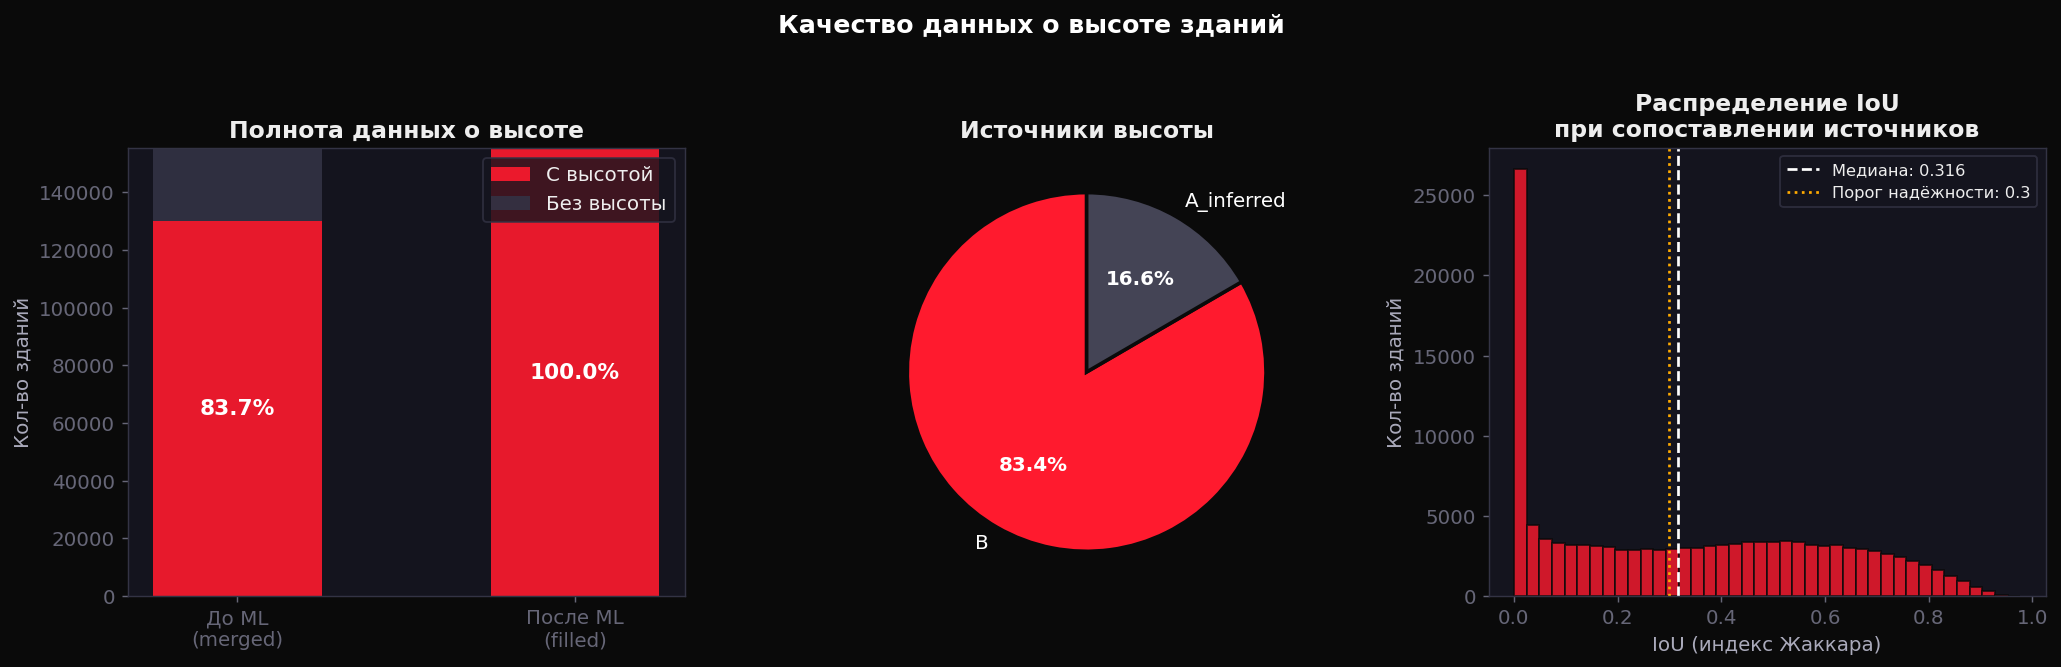

In [4]:
# Визуализация: полнота и источники
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Качество данных о высоте зданий', fontsize=14, color=WHITE, fontweight='bold', y=1.02)

# Полнота до/после
ax = axes[0]
merged_no  = merged['final_height_m'].isna().sum() if 'final_height_m' in merged.columns else len(merged)
merged_yes = len(merged) - merged_no
filled_yes = filled['final_height_m'].notna().sum()

cats = ['До ML\n(merged)', 'После ML\n(filled)']
yes_vals = [merged_yes, filled_yes]
no_vals  = [merged_no, len(filled) - filled_yes]

x = np.arange(2)
b1 = ax.bar(x, yes_vals, color=RED, alpha=0.9, label='С высотой', width=0.5)
b2 = ax.bar(x, no_vals, bottom=yes_vals, color='#333344', alpha=0.9, label='Без высоты', width=0.5)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_title('Полнота данных о высоте')
ax.set_ylabel('Кол-во зданий')
ax.legend(facecolor=CARD, edgecolor='#333344')
for i, (y, n) in enumerate(zip(yes_vals, no_vals)):
    pct = y/(y+n)*100
    ax.text(i, y/2, f'{pct:.1f}%', ha='center', va='center',
            color=WHITE, fontweight='bold', fontsize=12)

# Источники высоты
ax = axes[1]
if 'height_source' in filled.columns:
    src = filled['height_source'].value_counts()
    colors_src = [RED, '#444455', '#666677', '#888899']
    wedges, texts, autotexts = ax.pie(
        src.values, labels=src.index,
        colors=colors_src[:len(src)],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': '#0A0A0A', 'linewidth': 2}
    )
    for t in texts: t.set_color(WHITE)
    for t in autotexts: t.set_color(WHITE); t.set_fontweight('bold')
ax.set_title('Источники высоты')

# IoU распределение
ax = axes[2]
if 'match_iou' in filled.columns:
    iou = filled['match_iou'].dropna()
    ax.hist(iou, bins=40, color=RED, alpha=0.8, edgecolor='#0A0A0A')
    ax.axvline(iou.median(), color=WHITE, linestyle='--', linewidth=1.5,
               label=f'Медиана: {iou.median():.3f}')
    ax.axvline(0.3, color='#FFAA00', linestyle=':', linewidth=1.5,
               label='Порог надёжности: 0.3')
    ax.set_xlabel('IoU (индекс Жаккара)')
    ax.set_ylabel('Кол-во зданий')
    ax.set_title('Распределение IoU\nпри сопоставлении источников')
    ax.legend(facecolor=CARD, edgecolor='#333344', fontsize=9)

plt.tight_layout()
plt.show()

### Выводы: качество данных

**Полнота** — после применения ML-модели достигнута 100% полнота. До ML часть зданий не имела высоты

**Источники:** 83.4% зданий получили высоту напрямую из источника Б (реальные данные). 16.6% (25 832 здания) — предсказаны ML-моделью (`A_inferred`)

**IoU сопоставления:** медиана 0.316 — прямо на пороге надёжности 0.3. 29.5% сопоставлений имеют IoU < 0.1 — это зоны где геометрия источников сильно расходится. 25 811 зданий (16.6%) не нашли пару в источнике Б вообще

---
# Раздел 3. Сравнение до и после ML

Что изменилось после применения модели? Как ML заполнил пропуски и насколько корректно?

In [5]:
# Сравнение распределений высот по источнику
if 'height_source' in filled.columns and 'final_height_m' in filled.columns:
    src_b  = filled[filled['height_source'] == 'B']['final_height_m'].dropna()
    src_ml = filled[filled['height_source'] == 'A_inferred']['final_height_m'].dropna()

    print('СРАВНЕНИЕ: Источник Б (реальные) vs ML-предсказание')
    print('─'*55)
    stats = pd.DataFrame({
        'Источник Б (реальные)': src_b.describe(),
        'A_inferred (ML)':       src_ml.describe()
    }).round(2)
    print(stats.to_string())
    print()
    print(f'  Разница медиан: {src_b.median():.1f}м (Б) vs {src_ml.median():.1f}м (ML)')
    print(f'  Разница средних: {src_b.mean():.1f}м (Б) vs {src_ml.mean():.1f}м (ML)')
    print()
    pct_above15 = (src_ml > 15).mean() * 100
    print(f'\n  ML зданий выше 15м: {(src_ml>15).sum():,} ({pct_above15:.1f}%) — модель адекватна.')

СРАВНЕНИЕ: Источник Б (реальные) vs ML-предсказание
───────────────────────────────────────────────────────
       Источник Б (реальные)  A_inferred (ML)
count              129607.00         25832.00
mean                   14.09             5.64
std                    13.24             8.18
min                     2.50             3.00
25%                     4.50             4.48
50%                     8.00             4.51
75%                    18.00             4.60
max                    84.00            99.00

  Разница медиан: 8.0м (Б) vs 4.5м (ML)
  Разница средних: 14.1м (Б) vs 5.6м (ML)


  ML зданий выше 15м: 440 (1.7%) — модель адекватна.


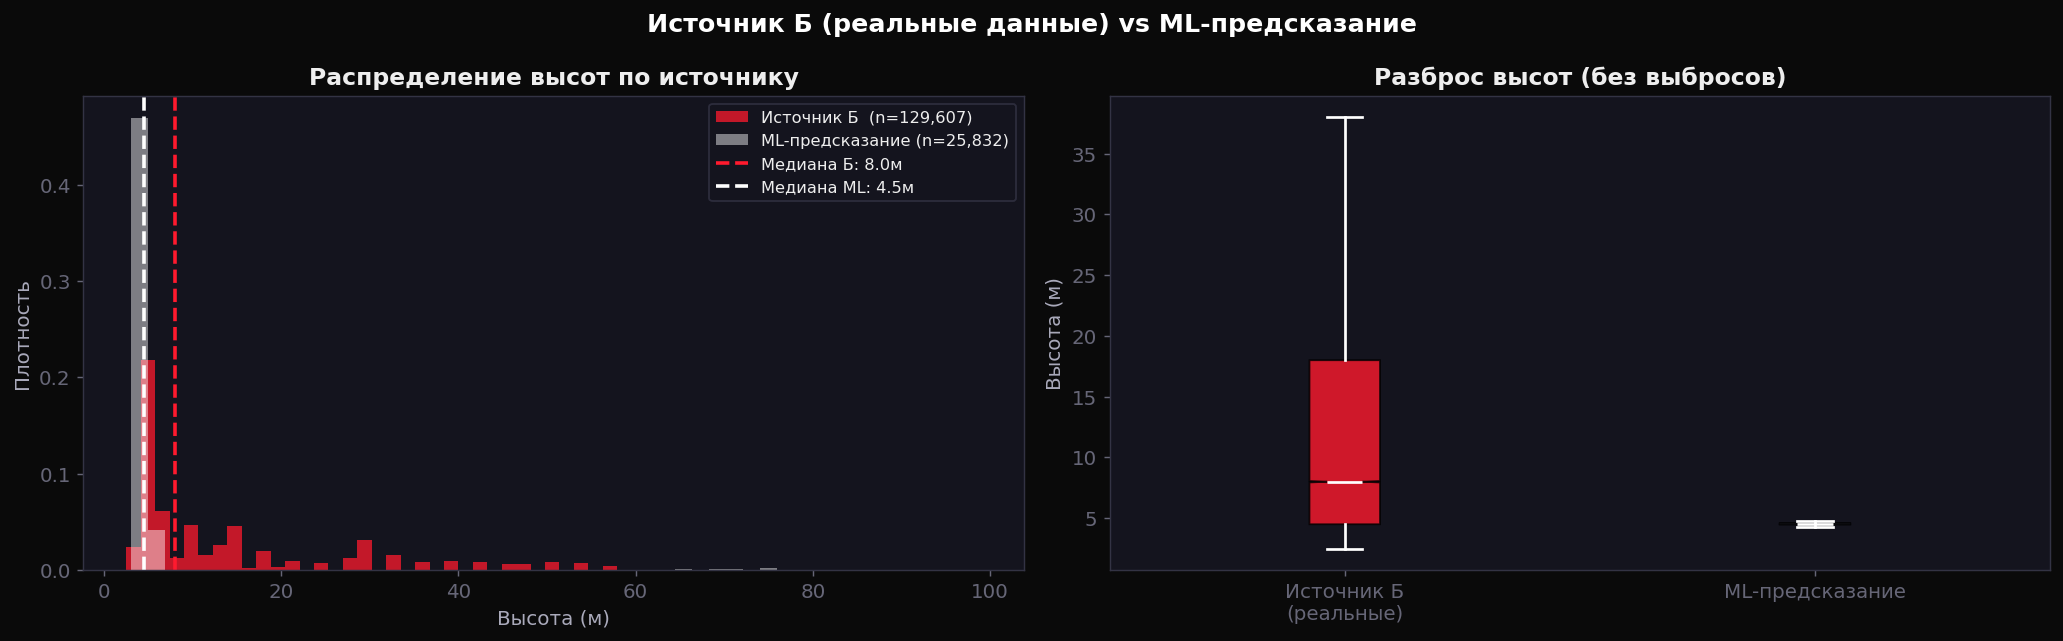

In [6]:
# Визуализация: Б vs ML
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Источник Б (реальные данные) vs ML-предсказание',
             fontsize=14, color=WHITE, fontweight='bold')

src_b  = filled[filled['height_source'] == 'B']['final_height_m'].dropna()
src_ml = filled[filled['height_source'] == 'A_inferred']['final_height_m'].dropna()

# Гистограммы
ax = axes[0]
ax.hist(src_b.clip(0, 100),  bins=50, color=RED,    alpha=0.75,
        label=f'Источник Б  (n={len(src_b):,})', density=True)
ax.hist(src_ml.clip(0, 100), bins=50, color=WHITE,  alpha=0.45,
        label=f'ML-предсказание (n={len(src_ml):,})', density=True)
ax.axvline(src_b.median(),  color=RED,   linestyle='--', lw=2,
           label=f'Медиана Б: {src_b.median():.1f}м')
ax.axvline(src_ml.median(), color=WHITE, linestyle='--', lw=2,
           label=f'Медиана ML: {src_ml.median():.1f}м')
ax.set_xlabel('Высота (м)')
ax.set_ylabel('Плотность')
ax.set_title('Распределение высот по источнику')
ax.legend(facecolor=CARD, edgecolor='#333344', fontsize=9)

# Boxplot
ax = axes[1]
data_bp = [src_b.clip(0, 100).values, src_ml.clip(0, 100).values]
bp = ax.boxplot(data_bp, labels=['Источник Б\n(реальные)', 'ML-предсказание'],
                patch_artist=True, notch=True, showfliers=False)
colors_bp = [RED, '#444455']
for patch, c in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(c); patch.set_alpha(0.8)
for el in ['whiskers', 'caps', 'medians']:
    for line in bp[el]: line.set_color(WHITE); line.set_linewidth(1.5)
ax.set_ylabel('Высота (м)')
ax.set_title('Разброс высот (без выбросов)')

plt.tight_layout()
plt.show()

### Выводы:

- Здания без пары в Б — это преимущественно мелкие объекты: гаражи, хозпостройки, складские помещения
- Только **1.7%** ML-зданий предсказаны выше 15м — модель корректно идентифицирует их как малоэтажные
- Максимум ML-предсказания 99м говорит что модель умеет распознавать и высокие объекты когда есть признаки

**Вывод:**  ML адекватно отражает реальность для неизвестных зданий

---
# Раздел 4. Анализ высотности

Полная картина высотности города — распределение, типы зданий, аномалии

In [7]:
# Распределение высот по бинам
bins   = [0, 5, 10, 15, 20, 30, 50, 100]
labels = ['0–5м', '5–10м', '10–15м', '15–20м', '20–30м', '30–50м', '50–100м']
filled['height_bin'] = pd.cut(filled['final_height_m'], bins=bins, labels=labels)

bin_counts = filled['height_bin'].value_counts().sort_index()

print('РАСПРЕДЕЛЕНИЕ ВЫСОТ ЗДАНИЙ СПб')
print('─'*55)
for lbl, cnt in bin_counts.items():
    pct  = cnt / len(filled) * 100
    bar  = '█' * int(pct * 1.2)
    approx = {'0–5м':'≈1–2 эт.','5–10м':'≈2–3 эт.','10–15м':'≈3–4 эт.',
               '15–20м':'≈5 эт. (хрущёвки)','20–30м':'≈7–9 эт. (панельки)',
               '30–50м':'≈10–15 эт. (новые ЖК)','50–100м':'≈17–33 эт. (высотки)'}
    print(f'  {lbl:<9} {cnt:>7,}  ({pct:5.1f}%)  {bar:<25}  {approx[lbl]}')
print(f'\n  Итого: {len(filled):,} зданий')
print(f'  Медиана: {filled["final_height_m"].median():.1f}м  |  Среднее: {filled["final_height_m"].mean():.1f}м')

РАСПРЕДЕЛЕНИЕ ВЫСОТ ЗДАНИЙ СПб
───────────────────────────────────────────────────────
  0–5м       74,944  ( 48.2%)  █████████████████████████████████████████████████████████  ≈1–2 эт.
  5–10м      27,305  ( 17.6%)  █████████████████████      ≈2–3 эт.
  10–15м     18,461  ( 11.9%)  ██████████████             ≈3–4 эт.
  15–20м      5,516  (  3.5%)  ████                       ≈5 эт. (хрущёвки)
  20–30м     12,897  (  8.3%)  █████████                  ≈7–9 эт. (панельки)
  30–50м     11,649  (  7.5%)  ████████                   ≈10–15 эт. (новые ЖК)
  50–100м     4,667  (  3.0%)  ███                        ≈17–33 эт. (высотки)

  Итого: 155,439 зданий
  Медиана: 6.6м  |  Среднее: 12.7м


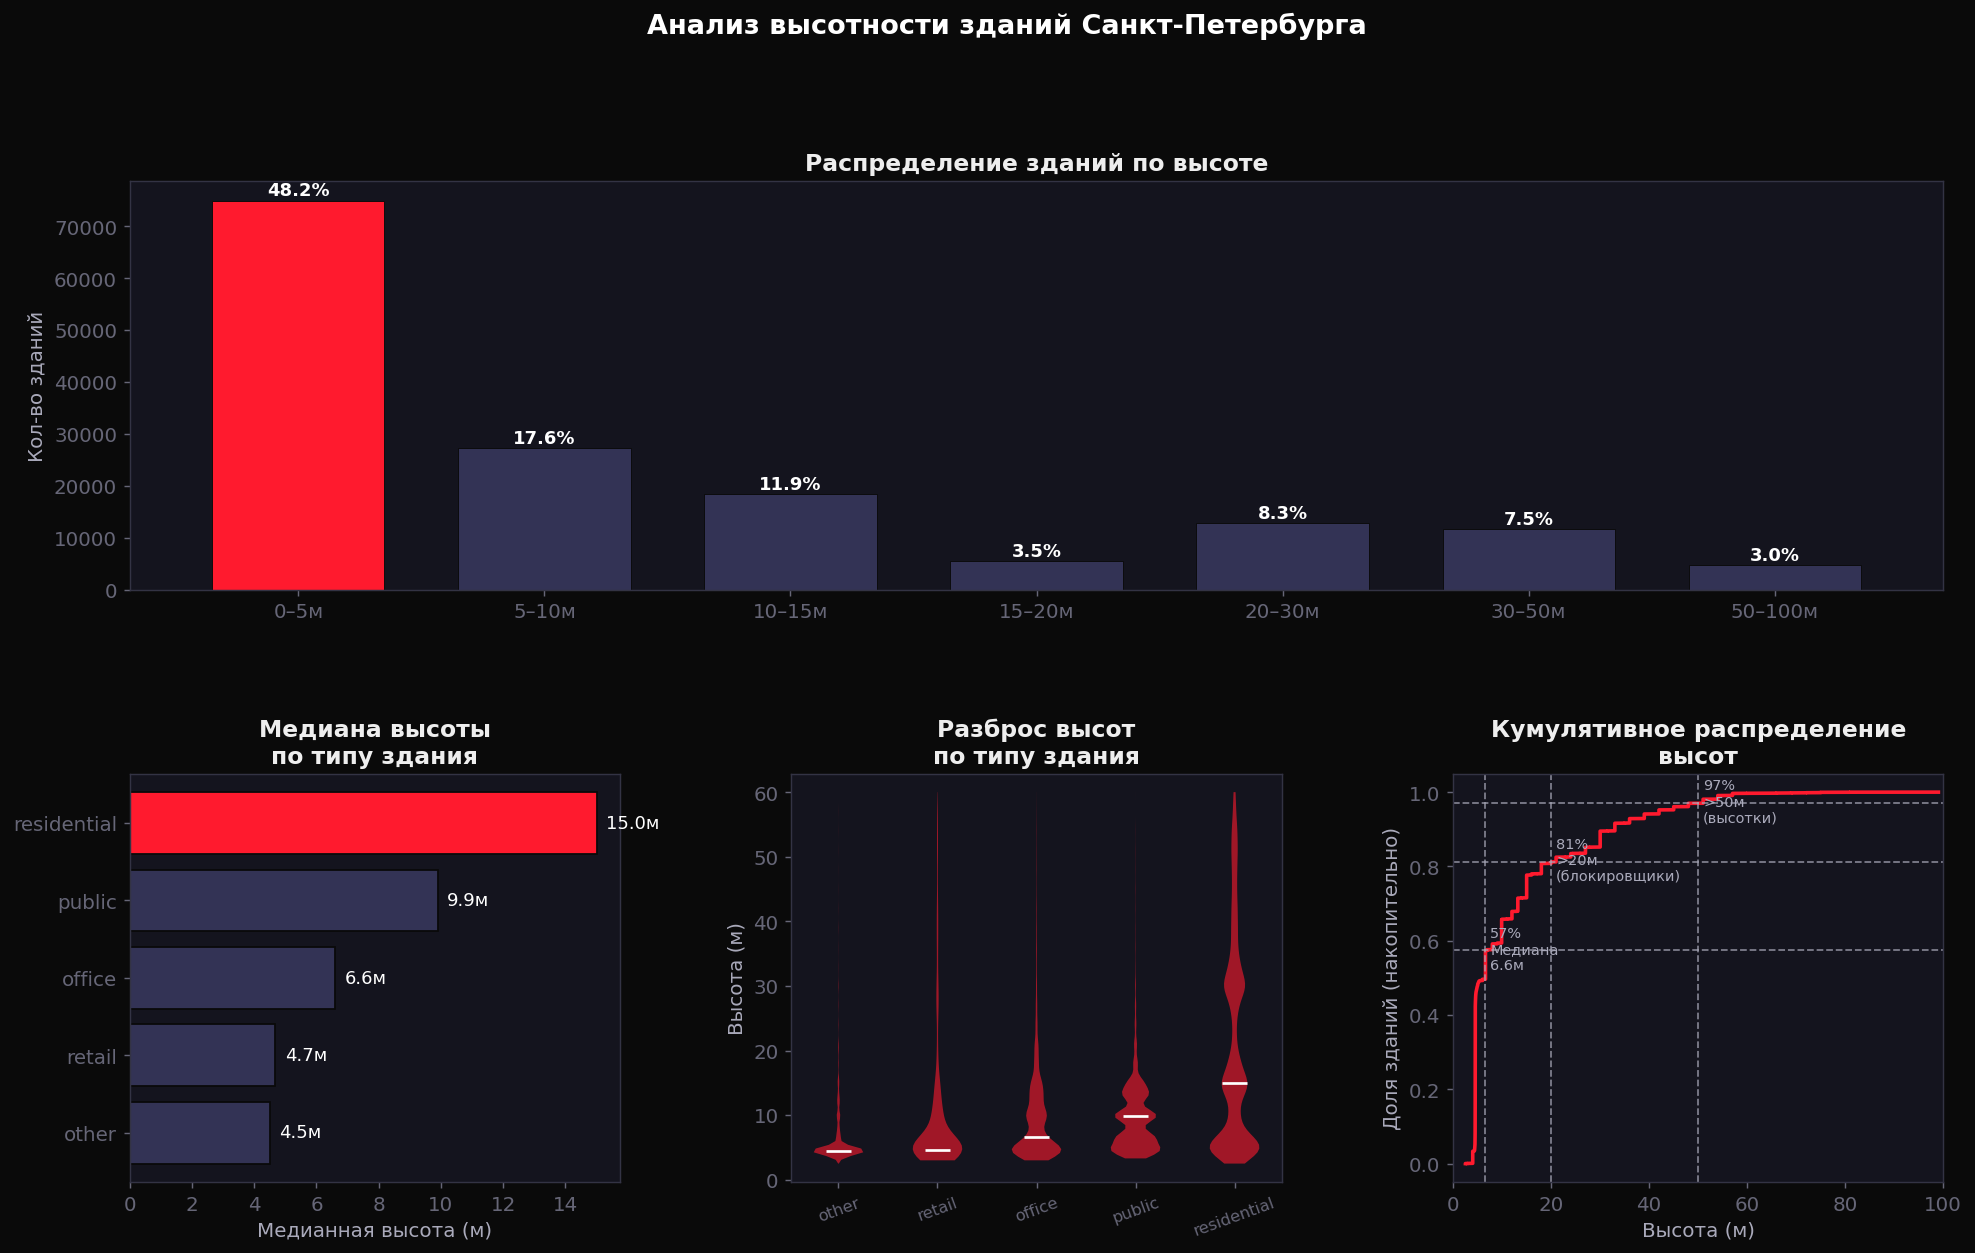

In [8]:
# Визуализация: высоты и типы
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0A0A0A')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Анализ высотности зданий Санкт-Петербурга',
             fontsize=15, color=WHITE, fontweight='bold', y=1.01)

# Бары по бинам
ax1 = fig.add_subplot(gs[0, :])
x    = np.arange(len(bin_counts))
vals = bin_counts.values
colors_bar = [RED if v == vals.max() else '#333355' for v in vals]
bars = ax1.bar(x, vals, color=colors_bar, edgecolor='#0A0A0A', linewidth=0.5, width=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylabel('Кол-во зданий')
ax1.set_title('Распределение зданий по высоте')
for bar, val in zip(bars, vals):
    pct = val / len(filled) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10,
             color=WHITE, fontweight='bold')

# Высота по типу здания
ax2 = fig.add_subplot(gs[1, 0])
if 'feat_building_type' in filled.columns:
    btype = filled.groupby('feat_building_type')['final_height_m'].median().sort_values(ascending=True)
    colors_t = [RED if v == btype.max() else '#333355' for v in btype.values]
    ax2.barh(btype.index, btype.values, color=colors_t, edgecolor='#0A0A0A')
    for i, v in enumerate(btype.values):
        ax2.text(v + 0.3, i, f'{v:.1f}м', va='center', color=WHITE, fontsize=10)
    ax2.set_xlabel('Медианная высота (м)')
    ax2.set_title('Медиана высоты\nпо типу здания')

# Violin plot по типу
ax3 = fig.add_subplot(gs[1, 1])
if 'feat_building_type' in filled.columns:
    order = filled.groupby('feat_building_type')['final_height_m'].median().sort_values().index
    data_v = [filled[filled['feat_building_type']==t]['final_height_m'].clip(0,60).dropna()
               for t in order]
    parts = ax3.violinplot(data_v, positions=range(len(order)),
                            showmedians=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(RED); pc.set_alpha(0.6)
    parts['cmedians'].set_color(WHITE)
    ax3.set_xticks(range(len(order)))
    ax3.set_xticklabels(order, rotation=20, fontsize=9)
    ax3.set_ylabel('Высота (м)')
    ax3.set_title('Разброс высот\nпо типу здания')

# Кумулятивное распределение
ax4 = fig.add_subplot(gs[1, 2])
h_sorted = np.sort(filled['final_height_m'].dropna())
cdf = np.arange(1, len(h_sorted)+1) / len(h_sorted)
ax4.plot(h_sorted, cdf, color=RED, linewidth=2)
for threshold, label in [(6.6, 'Медиана\n6.6м'), (20, '>20м\n(блокировщики)'), (50, '>50м\n(высотки)')]:
    pct_below = (h_sorted <= threshold).mean()
    ax4.axvline(threshold, color=GREY, linestyle='--', linewidth=1, alpha=0.7)
    ax4.axhline(pct_below,  color=GREY, linestyle='--', linewidth=1, alpha=0.7)
    ax4.text(threshold+1, pct_below-0.05, f'{pct_below*100:.0f}%\n{label}',
             color=GREY, fontsize=8)
ax4.set_xlabel('Высота (м)')
ax4.set_ylabel('Доля зданий (накопительно)')
ax4.set_title('Кумулятивное распределение\nвысот')
ax4.set_xlim(0, 100)

plt.tight_layout()
plt.show()

### Выводы: высотность города

**Город преимущественно малоэтажный:** 48.2% зданий ниже 5м — это одноэтажные постройки, гаражи, хозяйственные объекты

**Аномалия в распределении:** провал на 15–20м (всего 3.5%) с последующим ростом на 20–30м. Это классическая картина СПб — хрущёвки (5 эт., ≈15м) немногочисленны, зато советских 9-этажных панелек (≈27м) много

**Жилые здания втрое выше остальных:** медиана 15.0м против 4.5м у нежилых. Жилой фонд — главное препятствие для сигнала

**Хвост высоток:** 18.8% зданий выше 20м (29 213) — потенциальные блокировщики. 4 667 зданий выше 50м — серьёзные высотки

### 

---
# Раздел 5. Блокировщики сигнала

Здания выше соседей — главная угроза для точности расчётов покрытия

In [9]:
# Анализ блокировщиков
h = filled['final_height_m']

thresholds = [10, 15, 20, 30, 50]
print('ЗДАНИЯ-БЛОКИРОВЩИКИ ПО ПОРОГУ ВЫСОТЫ')
print('─'*55)
for t in thresholds:
    cnt = (h > t).sum()
    pct = cnt / len(filled) * 100
    bar = '█' * int(pct)
    print(f'  > {t:>3}м:  {cnt:>7,}  ({pct:5.1f}%)  {bar}')

# Блокировщики относительно соседей
if 'feat_avg_neighbor_height_100m' in filled.columns:
    filled['height_vs_neighbors'] = (
        filled['final_height_m'] -
        pd.to_numeric(filled['feat_avg_neighbor_height_100m'], errors='coerce')
    )
    blockers_20 = filled[filled['height_vs_neighbors'] > 20]
    blockers_10 = filled[filled['height_vs_neighbors'] > 10]
    print(f'\nБЛОКИРОВЩИКИ ОТНОСИТЕЛЬНО СОСЕДЕЙ (радиус 100м):')
    print(f'  Выше соседей на >10м: {len(blockers_10):,} ({len(blockers_10)/len(filled)*100:.1f}%)')
    print(f'  Выше соседей на >20м: {len(blockers_20):,} ({len(blockers_20)/len(filled)*100:.1f}%)')

ЗДАНИЯ-БЛОКИРОВЩИКИ ПО ПОРОГУ ВЫСОТЫ
───────────────────────────────────────────────────────
  >  10м:   53,190  ( 34.2%)  ██████████████████████████████████
  >  15м:   34,729  ( 22.3%)  ██████████████████████
  >  20м:   29,213  ( 18.8%)  ██████████████████
  >  30м:   16,316  ( 10.5%)  ██████████
  >  50м:    4,667  (  3.0%)  ███

БЛОКИРОВЩИКИ ОТНОСИТЕЛЬНО СОСЕДЕЙ (радиус 100м):
  Выше соседей на >10м: 3,999 (2.6%)
  Выше соседей на >20м: 673 (0.4%)


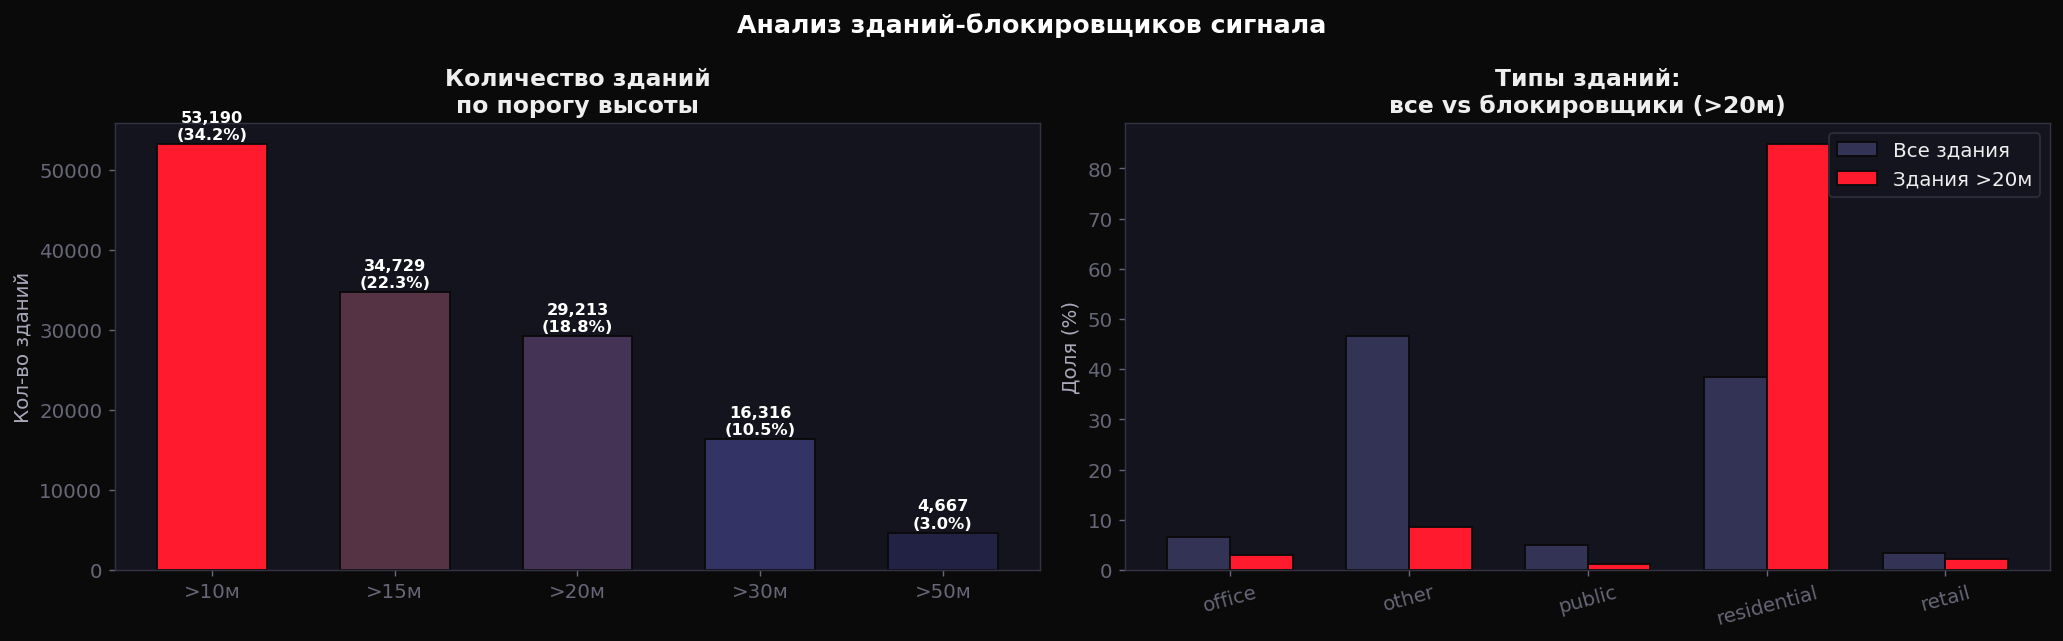

In [10]:
# Визуализация блокировщиков
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Анализ зданий-блокировщиков сигнала',
             fontsize=14, color=WHITE, fontweight='bold')

# Воронка блокировщиков
ax = axes[0]
thr_labels = [f'>10м', f'>15м', f'>20м', f'>30м', f'>50м']
thr_vals   = [(h > t).sum() for t in [10, 15, 20, 30, 50]]
colors_f   = [RED if i == 0 else f'#{hex(0x33 + i*0x11)[2:]}3355' for i in range(5)]
bars = ax.bar(thr_labels, thr_vals, color=[RED,'#553344','#443355','#333366','#222244'],
              edgecolor='#0A0A0A', width=0.6)
for bar, val in zip(bars, thr_vals):
    pct = val / len(filled) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
            color=WHITE, fontsize=9, fontweight='bold')
ax.set_ylabel('Кол-во зданий')
ax.set_title('Количество зданий\nпо порогу высоты')

# Топ типы среди высоких зданий
ax = axes[1]
if 'feat_building_type' in filled.columns:
    high = filled[filled['final_height_m'] > 20]
    all_types = filled['feat_building_type'].value_counts(normalize=True) * 100
    high_types = high['feat_building_type'].value_counts(normalize=True) * 100
    compare = pd.DataFrame({'Все здания': all_types, 'Здания >20м': high_types}).fillna(0)
    x2 = np.arange(len(compare))
    w  = 0.35
    ax.bar(x2 - w/2, compare['Все здания'],  width=w, color='#333355', label='Все здания', edgecolor='#0A0A0A')
    ax.bar(x2 + w/2, compare['Здания >20м'], width=w, color=RED,       label='Здания >20м', edgecolor='#0A0A0A')
    ax.set_xticks(x2); ax.set_xticklabels(compare.index, rotation=15)
    ax.set_ylabel('Доля (%)')
    ax.set_title('Типы зданий:\nвсе vs блокировщики (>20м)')
    ax.legend(facecolor=CARD, edgecolor='#333344')

plt.tight_layout()
plt.show()

### Выводы: блокировщики сигнала

**29 213 зданий (18.8%)** выше 20м — потенциальные блокировщики сигнала

**4 667 зданий (3.0%)** выше 50м — серьёзные высотки, требующие индивидуального учёта при моделировании покрытия в Atoll/Planet EV

**Для МТС:** эти здания нужно внести отдельным слоем в систему планирования. Ошибка в высоте даже одного высокого здания может привести к «дыре» в покрытии на несколько кварталов

---
# Раздел 6 Сеточный анализ города (500м × 500м)

Делим Санкт-Петербург на ячейки 500×500 метров и считаем в каждой:
- среднюю и медианную высоту зданий
- плотность застройки
- разнобой высот (CV)
- долю зданий без надёжной высоты

Это основа для тепловых карт и классификации зон

In [11]:
# Координаты
CELL_SIZE = 500  # метры

if 'feat_x_coord' in filled.columns and 'feat_y_coord' in filled.columns:
    gdf = filled.copy()
    gdf['x'] = pd.to_numeric(gdf['feat_x_coord'], errors='coerce')
    gdf['y'] = pd.to_numeric(gdf['feat_y_coord'], errors='coerce')
    print('Координаты взяты из feat_x_coord / feat_y_coord')
else:
    # Если нет проекционных координат — используем lon/lat как прокси
    try:
        from shapely import wkt as swkt
        print('Вычисляем центроиды из геометрии...')
        geoms = filled['geometry_wkt'].apply(lambda x: swkt.loads(str(x)))
        gdf = filled.copy()
        gdf['x'] = geoms.apply(lambda g: g.centroid.x) * 111320  # lon → метры (прибл.)
        gdf['y'] = geoms.apply(lambda g: g.centroid.y) * 110540  # lat → метры (прибл.)
        print('Координаты вычислены из геометрии')
    except Exception as e:
        print(f'Не удалось получить координаты: {e}')
        gdf = None

if gdf is not None:
    gdf = gdf[gdf['x'].notna() & gdf['y'].notna()].copy()
    gdf['grid_x'] = (gdf['x'] // CELL_SIZE).astype(int)
    gdf['grid_y'] = (gdf['y'] // CELL_SIZE).astype(int)
    n_cells = gdf.groupby(['grid_x','grid_y']).ngroups
    print(f'\n  Зданий с координатами: {len(gdf):,}')
    print(f'  Уникальных ячеек:      {n_cells:,}')
    print(f'  Размер ячейки:         {CELL_SIZE}м × {CELL_SIZE}м')

Координаты взяты из feat_x_coord / feat_y_coord

  Зданий с координатами: 155,439
  Уникальных ячеек:      8,066
  Размер ячейки:         500м × 500м


In [12]:
# Агрегация по ячейкам
if gdf is not None:
    grid = gdf.groupby(['grid_x', 'grid_y']).agg(
        count_total    = ('area_sq_m',       'count'),
        count_height   = ('final_height_m',  'count'),
        mean_height    = ('final_height_m',  'mean'),
        median_height  = ('final_height_m',  'median'),
        std_height     = ('final_height_m',  'std'),
        max_height     = ('final_height_m',  'max'),
        p90_height     = ('final_height_m',  lambda s: s.quantile(0.9)),
        total_area     = ('area_sq_m',       'sum'),
        x_center       = ('x',              'mean'),
        y_center       = ('y',              'mean'),
        missing_height = ('final_height_m',  lambda s: s.isna().sum()),
    ).reset_index()

    cell_area = CELL_SIZE ** 2
    grid['density']      = grid['total_area']     / cell_area
    grid['cv_height']    = grid['std_height']     / grid['mean_height'].replace(0, np.nan)
    grid['missing_pct']  = grid['missing_height'] / grid['count_total'] * 100

    # Классификация зоны
    def classify_zone(row):
        h  = row['mean_height'] if pd.notna(row['mean_height']) else 0
        d  = row['density']     if pd.notna(row['density'])     else 0
        cv = row['cv_height']   if pd.notna(row['cv_height'])   else 0
        if d > 0.5 and h > 25:   return 'Плотная высотная'
        elif d > 0.5 and h <= 25: return 'Плотная малоэтажная'
        elif h > 50:              return 'Высотные объекты'
        elif cv > 0.5:            return 'Смешанная застройка'
        elif d < 0.15 and h < 8: return 'Малоэтажная / ИЖС'
        else:                    return 'Средняя застройка'

    grid['mts_zone'] = grid.apply(classify_zone, axis=1)

    print('СТАТИСТИКА СЕТКИ')
    print('─'*50)
    print(f'  Ячеек всего:               {len(grid):,}')
    print(f'  Медиана зданий в ячейке:   {grid["count_total"].median():.0f}')
    print(f'  Медиана плотности:         {grid["density"].median():.3f}')
    print(f'  Медиана средней высоты:    {grid["mean_height"].median():.1f}м')
    print(f'  Ячеек с >50% пропусков:   {(grid["missing_pct"]>50).sum():,}')
    print()
    print('РАСПРЕДЕЛЕНИЕ ЗОНАМИ МТС:')
    print('─'*50)
    for zone, cnt in grid['mts_zone'].value_counts().items():
        pct = cnt / len(grid) * 100
        print(f'  {zone:<25} {cnt:>5,} ячеек  ({pct:.1f}%)')

СТАТИСТИКА СЕТКИ
──────────────────────────────────────────────────
  Ячеек всего:               8,066
  Медиана зданий в ячейке:   16
  Медиана плотности:         0.022
  Медиана средней высоты:    8.1м
  Ячеек с >50% пропусков:   0

РАСПРЕДЕЛЕНИЕ ЗОНАМИ МТС:
──────────────────────────────────────────────────
  Смешанная застройка       3,843 ячеек  (47.6%)
  Малоэтажная / ИЖС         3,084 ячеек  (38.2%)
  Средняя застройка         1,132 ячеек  (14.0%)
  Высотные объекты              7 ячеек  (0.1%)


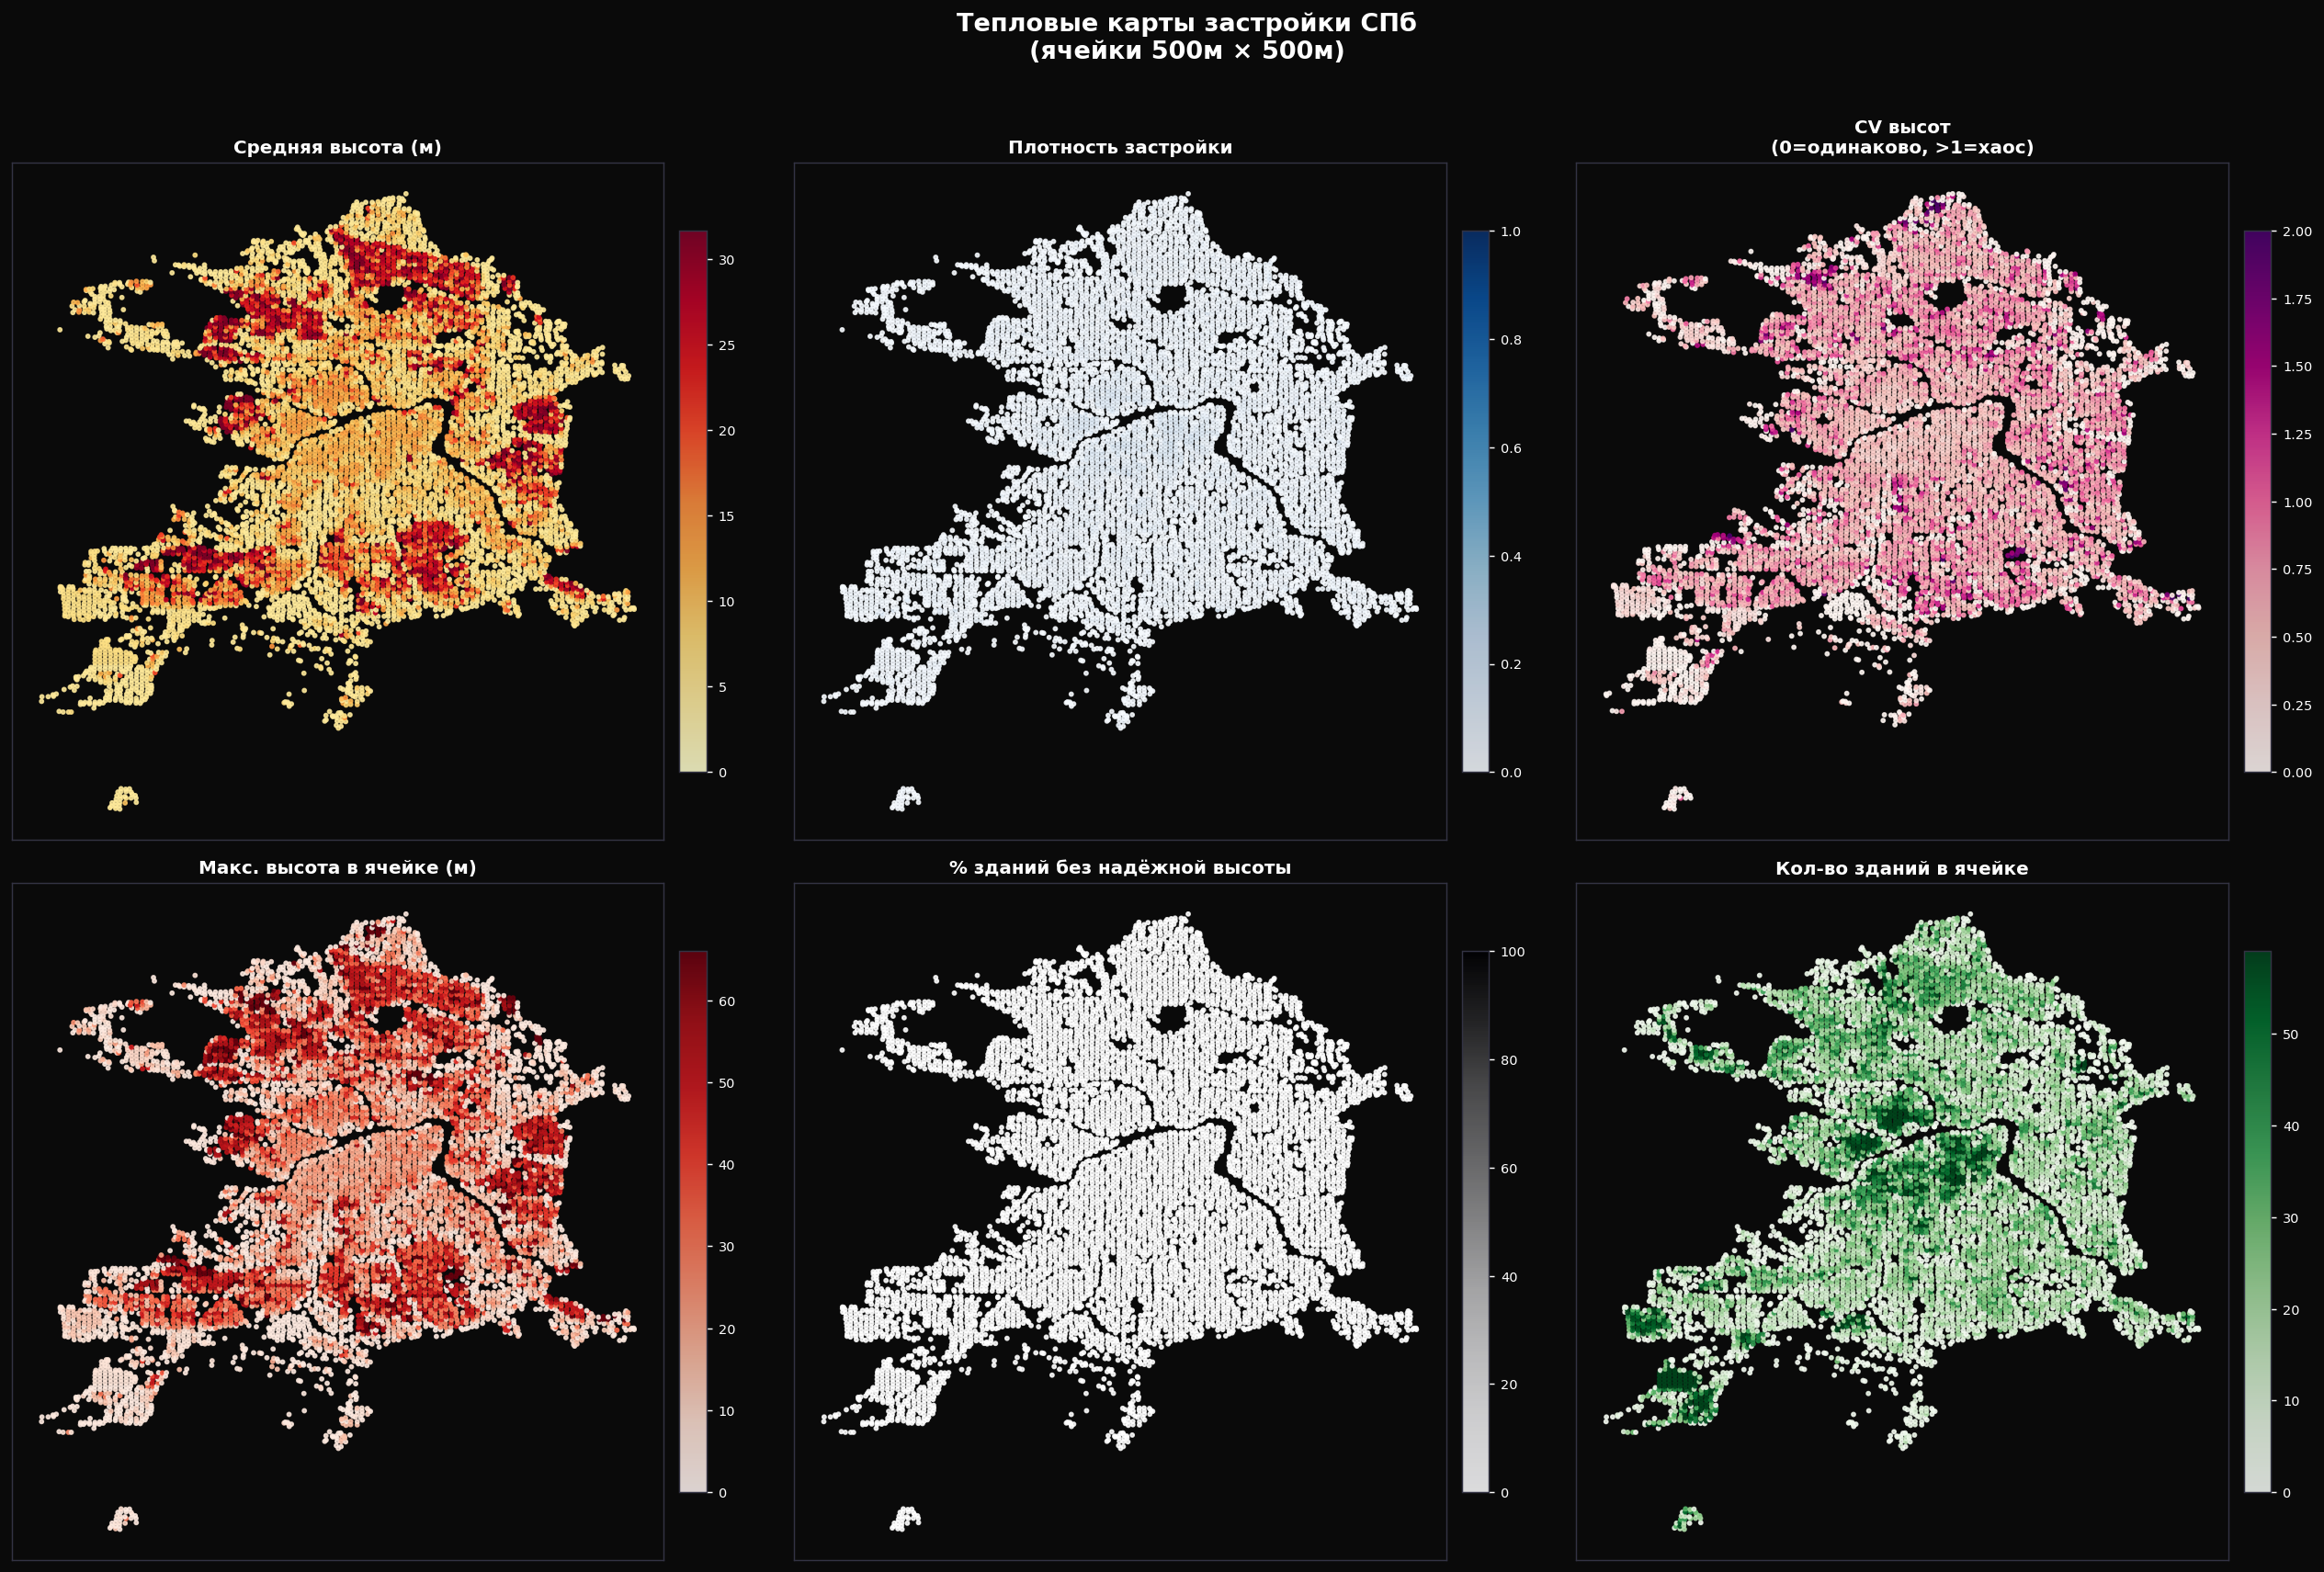

Тепловые карты сохранены: mts_heatmaps.png


In [13]:
# Тепловые карты: 6 метрик
if gdf is not None and len(grid) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    fig.patch.set_facecolor('#0A0A0A')
    fig.suptitle(f'Тепловые карты застройки СПб\n(ячейки {CELL_SIZE}м × {CELL_SIZE}м)',
                 fontsize=15, color='white', fontweight='bold', y=1.01)

    metrics = [
        ('mean_height',  'Средняя высота (м)',             'YlOrRd',   None),
        ('density',      'Плотность застройки',            'Blues',    1.0),
        ('cv_height',    'CV высот\n(0=одинаково, >1=хаос)', 'RdPu',  2.0),
        ('max_height',   'Макс. высота в ячейке (м)',      'Reds',     None),
        ('missing_pct',  '% зданий без надёжной высоты',   'Greys',    100),
        ('count_total',  'Кол-во зданий в ячейке',         'Greens',   None),
    ]

    for ax, (col, title, cmap, vmax) in zip(axes.flat, metrics):
        ax.set_facecolor('#0A0A0A')
        valid = grid[grid[col].notna()]
        vmax_val = vmax if vmax else valid[col].quantile(0.97)
        sc = ax.scatter(
            valid['x_center'], valid['y_center'],
            c=valid[col], cmap=cmap, s=5, alpha=0.85,
            vmin=0, vmax=vmax_val
        )
        cb = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
        cb.ax.yaxis.set_tick_params(color='white')
        cb.ax.tick_params(labelcolor='white', labelsize=8)
        ax.set_title(title, fontsize=11, color='white', fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#333344')

    plt.tight_layout()
    plt.savefig('mts_heatmaps.png', dpi=150, bbox_inches='tight',
                facecolor='#0A0A0A', edgecolor='none')
    plt.show()
    print('Тепловые карты сохранены: mts_heatmaps.png')

---
# Раздел 7. Профиль города: центр vs периферия

Как меняется высотность по мере удаления от центра СПб?

In [14]:
if 'feat_distance_to_center_km' in filled.columns:
    filled['dist_km'] = pd.to_numeric(filled['feat_distance_to_center_km'], errors='coerce')
    df_dist = filled[filled['dist_km'].notna() & filled['final_height_m'].notna()].copy()

    # Зоны
    zones = [('Центр (0–5 км)', 0, 5), ('Средний пояс (5–15 км)', 5, 15),
             ('Периферия (>15 км)', 15, 999)]
    print('ПРОФИЛЬ ГОРОДА ПО УДАЛЁННОСТИ ОТ ЦЕНТРА')
    print('─'*65)
    for name, d_min, d_max in zones:
        z = df_dist[(df_dist['dist_km'] >= d_min) & (df_dist['dist_km'] < d_max)]
        if len(z):
            print(f'  {name:<30}  n={len(z):>6,}  '
                  f'медиана={z["final_height_m"].median():.1f}м  '
                  f'среднее={z["final_height_m"].mean():.1f}м  '
                  f'макс={z["final_height_m"].max():.0f}м')

    # Бинируем по расстоянию
    df_dist['dist_bin'] = pd.cut(df_dist['dist_km'], bins=25)
    profile = df_dist.groupby('dist_bin', observed=True)['final_height_m'].agg(
        median='median', q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75), count='count'
    ).reset_index()
    profile['dist_center'] = profile['dist_bin'].apply(
        lambda b: (b.left + b.right) / 2).astype(float)

ПРОФИЛЬ ГОРОДА ПО УДАЛЁННОСТИ ОТ ЦЕНТРА
─────────────────────────────────────────────────────────────────
  Центр (0–5 км)                  n=10,537  медиана=13.2м  среднее=11.7м  макс=54м
  Средний пояс (5–15 км)          n=47,557  медиана=6.6м  среднее=11.5м  макс=81м
  Периферия (>15 км)              n=97,345  медиана=4.6м  среднее=13.4м  макс=99м


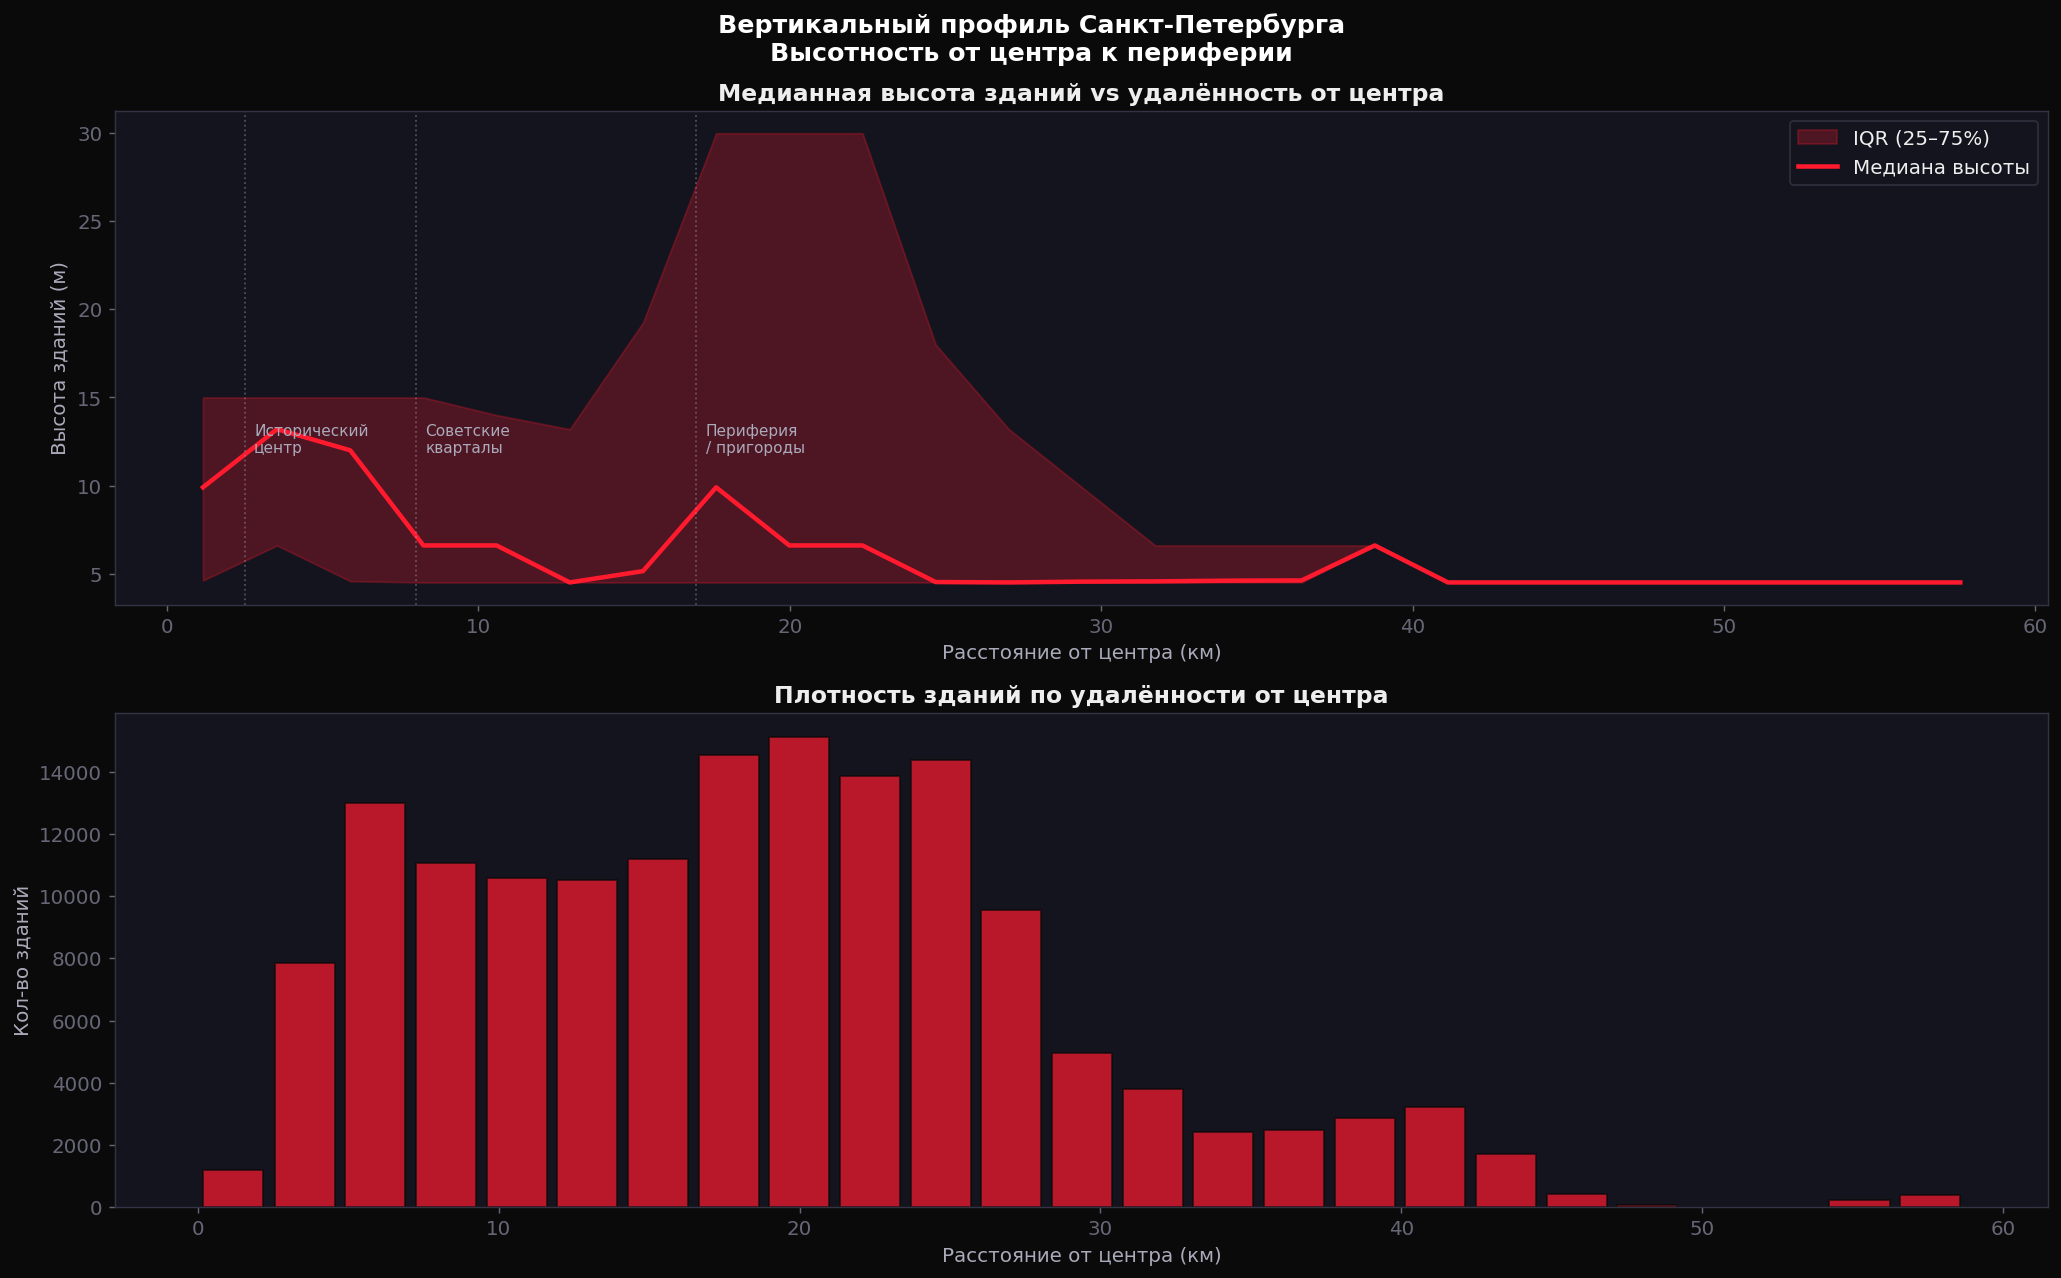

In [15]:
if 'feat_distance_to_center_km' in filled.columns:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Вертикальный профиль Санкт-Петербурга\nВысотность от центра к периферии',
                 fontsize=14, color=WHITE, fontweight='bold')

    # Профиль высот
    ax = axes[0]
    ax.fill_between(profile['dist_center'], profile['q25'], profile['q75'],
                    alpha=0.25, color=RED, label='IQR (25–75%)')
    ax.plot(profile['dist_center'], profile['median'],
            color=RED, linewidth=2.5, label='Медиана высоты')

    # Аннотации зон
    for x_pos, label, c in [
        (2.5, 'Исторический\nцентр', GREY),
        (8,   'Советские\nкварталы', GREY),
        (17,  'Периферия\n/ пригороды', GREY)
    ]:
        if x_pos <= df_dist['dist_km'].max():
            ax.axvline(x_pos, color=c, linestyle=':', alpha=0.4, linewidth=1)
            ax.text(x_pos+0.3, profile['median'].max()*0.9, label,
                    fontsize=8.5, color=c)

    ax.set_xlabel('Расстояние от центра (км)')
    ax.set_ylabel('Высота зданий (м)')
    ax.legend(facecolor=CARD, edgecolor='#333344')
    ax.set_title('Медианная высота зданий vs удалённость от центра')

    # Кол-во зданий по кольцам
    ax = axes[1]
    dist_vals = profile['dist_center'].astype(float)
    bar_width = float(dist_vals.diff().dropna().median()) * 0.85
    ax.bar(dist_vals, profile['count'], width=bar_width,
           color=RED, alpha=0.7, edgecolor='#0A0A0A')
    ax.set_xlabel('Расстояние от центра (км)')
    ax.set_ylabel('Кол-во зданий')
    ax.set_title('Плотность зданий по удалённости от центра')

    plt.tight_layout()
    plt.show()

### Выводы: профиль города

Профиль высотности отражает историю застройки СПб:

- **Центр (0–5 км):** исторические здания 3–5 этажей, медиана умеренная, плотная застройка — много отражений сигнала
- **Средний пояс (5–15 км):** пик высотности — советские 9-этажки и современные ЖК, самая сложная зона для планирования
- **Периферия (>15 км):** резкое снижение высотности, малоэтажная и частная застройка — одна вышка покрывает большой радиус

Разные зоны требуют принципиально разных стратегий размещения оборудования

---
# Раздел 8 Кластеризация зданий по 3 критериям
## Зоны качества покрытия сети МТС

---

### Идея

Стандартный подход к планированию сети учитывает только высоту зданий.  
Мы предлагаем **трёхкритериальную кластеризацию** которая даёт принципиально более точную картину

**Ключевое отличие от классического подхода:** вес типа здания рассчитан не экспертно,  
**data-driven** — на основе реальных медианных высот каждого типа в датасете

In [16]:
import ast
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.gridspec as gridspec

# Парсинг тегов
def parse_tags(val):
    if pd.isna(val): return []
    try:    return ast.literal_eval(val)
    except: return [str(val)]

filled['tags_parsed'] = filled['tags'].apply(parse_tags)

PRIORITY = {
    'жилое здание':          1,
    'Комплекс зданий':       2,
    'бизнес и услуги':       3,
    'промышленность':        4,
    'культура и отдых':      5,
    'постройка, сооружение': 6,
}

def get_primary_type(tags):
    if not tags: return 'прочее'
    valid = [t for t in tags if t in PRIORITY]
    if valid: return min(valid, key=lambda x: PRIORITY[x])
    return 'прочее'

filled['primary_type'] = filled['tags_parsed'].apply(get_primary_type)

print('ТИПЫ ЗДАНИЙ (после парсинга тегов):')
print('─'*45)
for t, cnt in filled['primary_type'].value_counts().items():
    print(f'  {t:<28} {cnt:>7,}  ({cnt/len(filled)*100:.1f}%)')

ТИПЫ ЗДАНИЙ (после парсинга тегов):
─────────────────────────────────────────────
  жилое здание                  59,641  (38.4%)
  постройка, сооружение         44,733  (28.8%)
  промышленность                20,530  (13.2%)
  прочее                        18,082  (11.6%)
  бизнес и услуги                7,838  (5.0%)
  Комплекс зданий                2,887  (1.9%)
  культура и отдых               1,728  (1.1%)


In [17]:
# Веса типов на основе реальных данных
type_stats = filled.groupby('primary_type')['final_height_m'].agg(
    медиана='median', среднее='mean', кол_во='count'
).round(2)

max_med = type_stats['медиана'].max()
type_stats['weight'] = (type_stats['медиана'] / max_med).round(3)

print('ОБОСНОВАНИЕ ВЕСОВ ТИПОВ ЗДАНИЙ')
print('(вес = медианная высота типа / макс. медианная высота)')
print('─'*58)
print(f'  {"Тип":<28} {"Медиана":>10} {"Вес":>8} {"Кол-во":>10}')
print('  ' + '─'*52)
for t, row in type_stats.sort_values('weight', ascending=False).iterrows():
    bar = '█' * int(row['weight'] * 20)
    print(f'  {t:<28} {row["медиана"]:>8.1f}м {row["weight"]:>8.3f}  {int(row["кол_во"]):>8,}  {bar}')

weight_map = type_stats['weight'].to_dict()
filled['type_weight'] = filled['primary_type'].map(weight_map).fillna(0.5)
print(f'\nВес назначен для {filled["type_weight"].notna().sum():,} зданий')

ОБОСНОВАНИЕ ВЕСОВ ТИПОВ ЗДАНИЙ
(вес = медианная высота типа / макс. медианная высота)
──────────────────────────────────────────────────────────
  Тип                             Медиана      Вес     Кол-во
  ────────────────────────────────────────────────────
  жилое здание                     15.0м    1.000    59,641  ████████████████████
  прочее                            8.0м    0.533    18,082  ██████████
  бизнес и услуги                   6.6м    0.440     7,838  ████████
  культура и отдых                  6.6м    0.440     1,728  ████████
  Комплекс зданий                   4.6м    0.305     2,887  ██████
  постройка, сооружение             4.5м    0.300    44,733  ██████
  промышленность                    4.5м    0.300    20,530  ██████

Вес назначен для 155,439 зданий


In [18]:
from sklearn.feature_selection import mutual_info_regression

print('ВЫЧИСЛЕНИЕ ОПТИМАЛЬНЫХ ВЕСОВ ДЛЯ ИНДЕКСА СЛОЖНОСТИ ПОКРЫТИЯ')
print('='*65)
print('\nМЕТОД: Взаимная информация (Mutual Information)')
print('─'*55)

features_df = filled[['final_height_m', 'feat_density_100m', 'type_weight']].fillna(
    filled[['final_height_m', 'feat_density_100m', 'type_weight']].median()
)

y = features_df['final_height_m']
X = features_df[['final_height_m', 'feat_density_100m', 'type_weight']]

mi = mutual_info_regression(X, y, random_state=42)

weights = mi / mi.sum()

names = ['Высота здания', 'Плотность застройки (100м)', 'Тип здания']

print('\nРезультаты:')
print('─'*55)
for name, mi_val, weight in zip(names, mi, weights):
    bar = '█' * int(weight * 40)
    print(f'\n  {name}:')
    print(f'    Взаимная информация: {mi_val:.4f}')
    print(f'    Вес: {weight:.3f}  {bar}')

print('\n' + '='*65)
print('ИТОГОВЫЕ ВЕСА (Метод взаимной информации)')
print('='*65)

w_height = round(weights[0], 2)
w_density = round(weights[1], 2)
w_type = round(weights[2], 2)

total = w_height + w_density + w_type
if total != 1.00:
    diff = 1.00 - total
    max_idx = np.argmax([w_height, w_density, w_type])
    if max_idx == 0:
        w_height += round(diff, 2)
    elif max_idx == 1:
        w_density += round(diff, 2)
    else:
        w_type += round(diff, 2)

print(f'\n  Итоговые веса:')
print(f'    W_HEIGHT  = {w_height}')
print(f'    W_DENSITY = {w_density}')
print(f'    W_TYPE    = {w_type}')
print(f'    Сумма:      {w_height + w_density + w_type:.2f}')

print(f'\n  Формула индекса сложности покрытия:')
print(f'    difficulty = {w_height} × (height / max_height) +')
print(f'                 {w_density} × (density / max_density) +')
print(f'                 {w_type} × type_weight')

print('\n' + '='*65)
print('💡 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ')
print('='*65)

if w_height > w_density and w_height > w_type:
    print('  Высота зданий — ключевой фактор сложности покрытия')
elif w_density > w_height and w_density > w_type:
    print('  Плотность застройки — ключевой фактор сложности покрытия')
else:
    print('  Тип здания — ключевой фактор сложности покрытия')

print(f'\n  Рекомендация для планирования сети:')
if w_height > 0.5:
    print('    Основной фокус на высотных зданиях')
elif w_density > 0.5:
    print('    Основной фокус на районах с высокой плотностью застройки')
else:
    print('    Учитывать тип зданий при выборе мест установки БС')

ВЫЧИСЛЕНИЕ ОПТИМАЛЬНЫХ ВЕСОВ ДЛЯ ИНДЕКСА СЛОЖНОСТИ ПОКРЫТИЯ

МЕТОД: Взаимная информация (Mutual Information)
───────────────────────────────────────────────────────

Результаты:
───────────────────────────────────────────────────────

  Высота здания:
    Взаимная информация: 4.0579
    Вес: 0.919  ████████████████████████████████████

  Плотность застройки (100м):
    Взаимная информация: 0.0571
    Вес: 0.013  

  Тип здания:
    Взаимная информация: 0.3025
    Вес: 0.068  ██

ИТОГОВЫЕ ВЕСА (Метод взаимной информации)

  Итоговые веса:
    W_HEIGHT  = 0.92
    W_DENSITY = 0.01
    W_TYPE    = 0.07
    Сумма:      1.00

  Формула индекса сложности покрытия:
    difficulty = 0.92 × (height / max_height) +
                 0.01 × (density / max_density) +
                 0.07 × type_weight

💡 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
  Высота зданий — ключевой фактор сложности покрытия

  Рекомендация для планирования сети:
    Основной фокус на высотных зданиях


### Почему это data-driven, а не экспертная оценка

Веса рассчитаны из **реальных данных датасета**: жилые здания имеют медианную высоту 15м,  
промышленные — ~8м, хозпостройки — ~4.5м Нормируем на максимум → получаем вес от 0 до 1

Это значит что **жилые здания автоматически получили наибольший вес** не потому что  
«эксперт так решил», а потому что они реально выше и создают больший барьер для сигнала 
Никаких магических констант — только данные

In [19]:
# Индекс сложности покрытия
W_HEIGHT  = 0.919
W_DENSITY = 0.013
W_TYPE    = 0.068

features = filled[['final_height_m', 'feat_density_100m', 'type_weight']].copy()
features = features.fillna(features.median())

scaler = MinMaxScaler()
scaled = scaler.fit_transform(features)

filled['coverage_difficulty'] = (
    W_HEIGHT  * scaled[:, 0] +
    W_DENSITY * scaled[:, 1] +
    W_TYPE    * scaled[:, 2]
)

print('ИНДЕКС СЛОЖНОСТИ ПОКРЫТИЯ')
print(f'  Формула: {W_HEIGHT}×высота + {W_DENSITY}×плотность + {W_TYPE}×тип_здания')
print('─'*50)
print(filled['coverage_difficulty'].describe().round(3).to_string())

# Квантильное распределение — для понимания разброса
print('\nКВАНТИЛИ ИНДЕКСА:')
for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
    val = filled['coverage_difficulty'].quantile(q)
    bar = '█' * int(val * 40)
    print(f'  P{int(q*100):>2}:  {val:.3f}  {bar}')

ИНДЕКС СЛОЖНОСТИ ПОКРЫТИЯ
  Формула: 0.919×высота + 0.013×плотность + 0.068×тип_здания
──────────────────────────────────────────────────
count    155439.000
mean          0.128
std           0.142
min           0.002
25%           0.021
50%           0.088
75%           0.182
max           0.987

КВАНТИЛИ ИНДЕКСА:
  P10:  0.020  
  P25:  0.021  
  P50:  0.088  ███
  P75:  0.182  ███████
  P90:  0.351  ██████████████


In [20]:
# Кластеризация KMeans на 3 зоны
cluster_input = pd.DataFrame(
    scaled, columns=['height_n', 'density_n', 'type_n'],
    index=filled.index
)
cluster_input['difficulty'] = filled['coverage_difficulty'].values

kmeans = KMeans(n_clusters=3, random_state=42, n_init=15)
filled['zone_raw'] = kmeans.fit_predict(cluster_input)

# Называем зоны по медиане индекса (от простой к сложной)
zone_med = filled.groupby('zone_raw')['coverage_difficulty'].median().sort_values()
zone_map = {
    zone_med.index[0]: 'Зона A — Лёгкое покрытие',
    zone_med.index[1]: 'Зона B — Среднее покрытие',
    zone_med.index[2]: 'Зона C — Сложное покрытие',
}
filled['coverage_zone'] = filled['zone_raw'].map(zone_map)

ZONE_ORDER = ['Зона A — Лёгкое покрытие',
              'Зона B — Среднее покрытие',
              'Зона C — Сложное покрытие']
COLORS = {
    'Зона A — Лёгкое покрытие':  '#39FF14',
    'Зона B — Среднее покрытие':  '#FFD700',
    'Зона C — Сложное покрытие':  '#FF1A2E',
}

# Итоговая статистика
print('═'*65)
print('  РЕЗУЛЬТАТ: 3 ЗОНЫ КАЧЕСТВА ПОКРЫТИЯ МТС')
print('═'*65)

stats = filled.groupby('coverage_zone').agg(
    кол_во            = ('final_height_m',      'count'),
    медиана_высоты    = ('final_height_m',      'median'),
    медиана_плотности = ('feat_density_100m',   'median'),
    медиана_индекса   = ('coverage_difficulty', 'median'),
).round(2)

recs = {
    'Зона A — Лёгкое покрытие':  '1 вышка на большой радиус, стандартная мощность',
    'Зона B — Среднее покрытие':  '2–3 станции, направленные антенны',
    'Зона C — Сложное покрытие':  'Много малых сот, тщательная калибровка',
}

for zone in ZONE_ORDER:
    if zone not in stats.index: continue
    row = stats.loc[zone]
    pct = row['кол_во'] / len(filled) * 100
    emoji = {'A':'🟢','B':'🟡','C':'🔴'}[zone.split()[1]]
    print(f'\n  {emoji} {zone}')
    print(f'    Зданий:             {int(row["кол_во"]):>7,}  ({pct:.1f}%)')
    print(f'    Медиана высоты:     {row["медиана_высоты"]:>7.1f} м')
    print(f'    Медиана плотности:  {row["медиана_плотности"]:>7.3f}')
    print(f'    Индекс сложности:   {row["медиана_индекса"]:>7.3f}')
    print(f'    Рекомендация МТС:   {recs[zone]}')

# Топ типы по зонам
print('\n  ТИПЫ ЗДАНИЙ В КАЖДОЙ ЗОНЕ:')
print('  ' + '─'*58)
for zone in ZONE_ORDER:
    sub = filled[filled['coverage_zone'] == zone]
    top = sub['primary_type'].value_counts().head(3)
    emoji = {'A':'🟢','B':'🟡','C':'🔴'}[zone.split()[1]]
    print(f'\n  {emoji} {zone}:')
    for t, cnt in top.items():
        pct = cnt / len(sub) * 100
        print(f'    {t:<28} {cnt:>6,}  ({pct:.1f}%)')

═════════════════════════════════════════════════════════════════
  РЕЗУЛЬТАТ: 3 ЗОНЫ КАЧЕСТВА ПОКРЫТИЯ МТС
═════════════════════════════════════════════════════════════════

  🟢 Зона A — Лёгкое покрытие
    Зданий:              95,696  (61.6%)
    Медиана высоты:         4.5 м
    Медиана плотности:    1.270
    Индекс сложности:     0.020
    Рекомендация МТС:   1 вышка на большой радиус, стандартная мощность

  🟡 Зона B — Среднее покрытие
    Зданий:              36,774  (23.7%)
    Медиана высоты:         6.6 м
    Медиана плотности:    1.910
    Индекс сложности:     0.110
    Рекомендация МТС:   2–3 станции, направленные антенны

  🔴 Зона C — Сложное покрытие
    Зданий:              22,969  (14.8%)
    Медиана высоты:        36.0 м
    Медиана плотности:    1.270
    Индекс сложности:     0.390
    Рекомендация МТС:   Много малых сот, тщательная калибровка

  ТИПЫ ЗДАНИЙ В КАЖДОЙ ЗОНЕ:
  ──────────────────────────────────────────────────────────

  🟢 Зона A — Лёгкое покрытие:
  

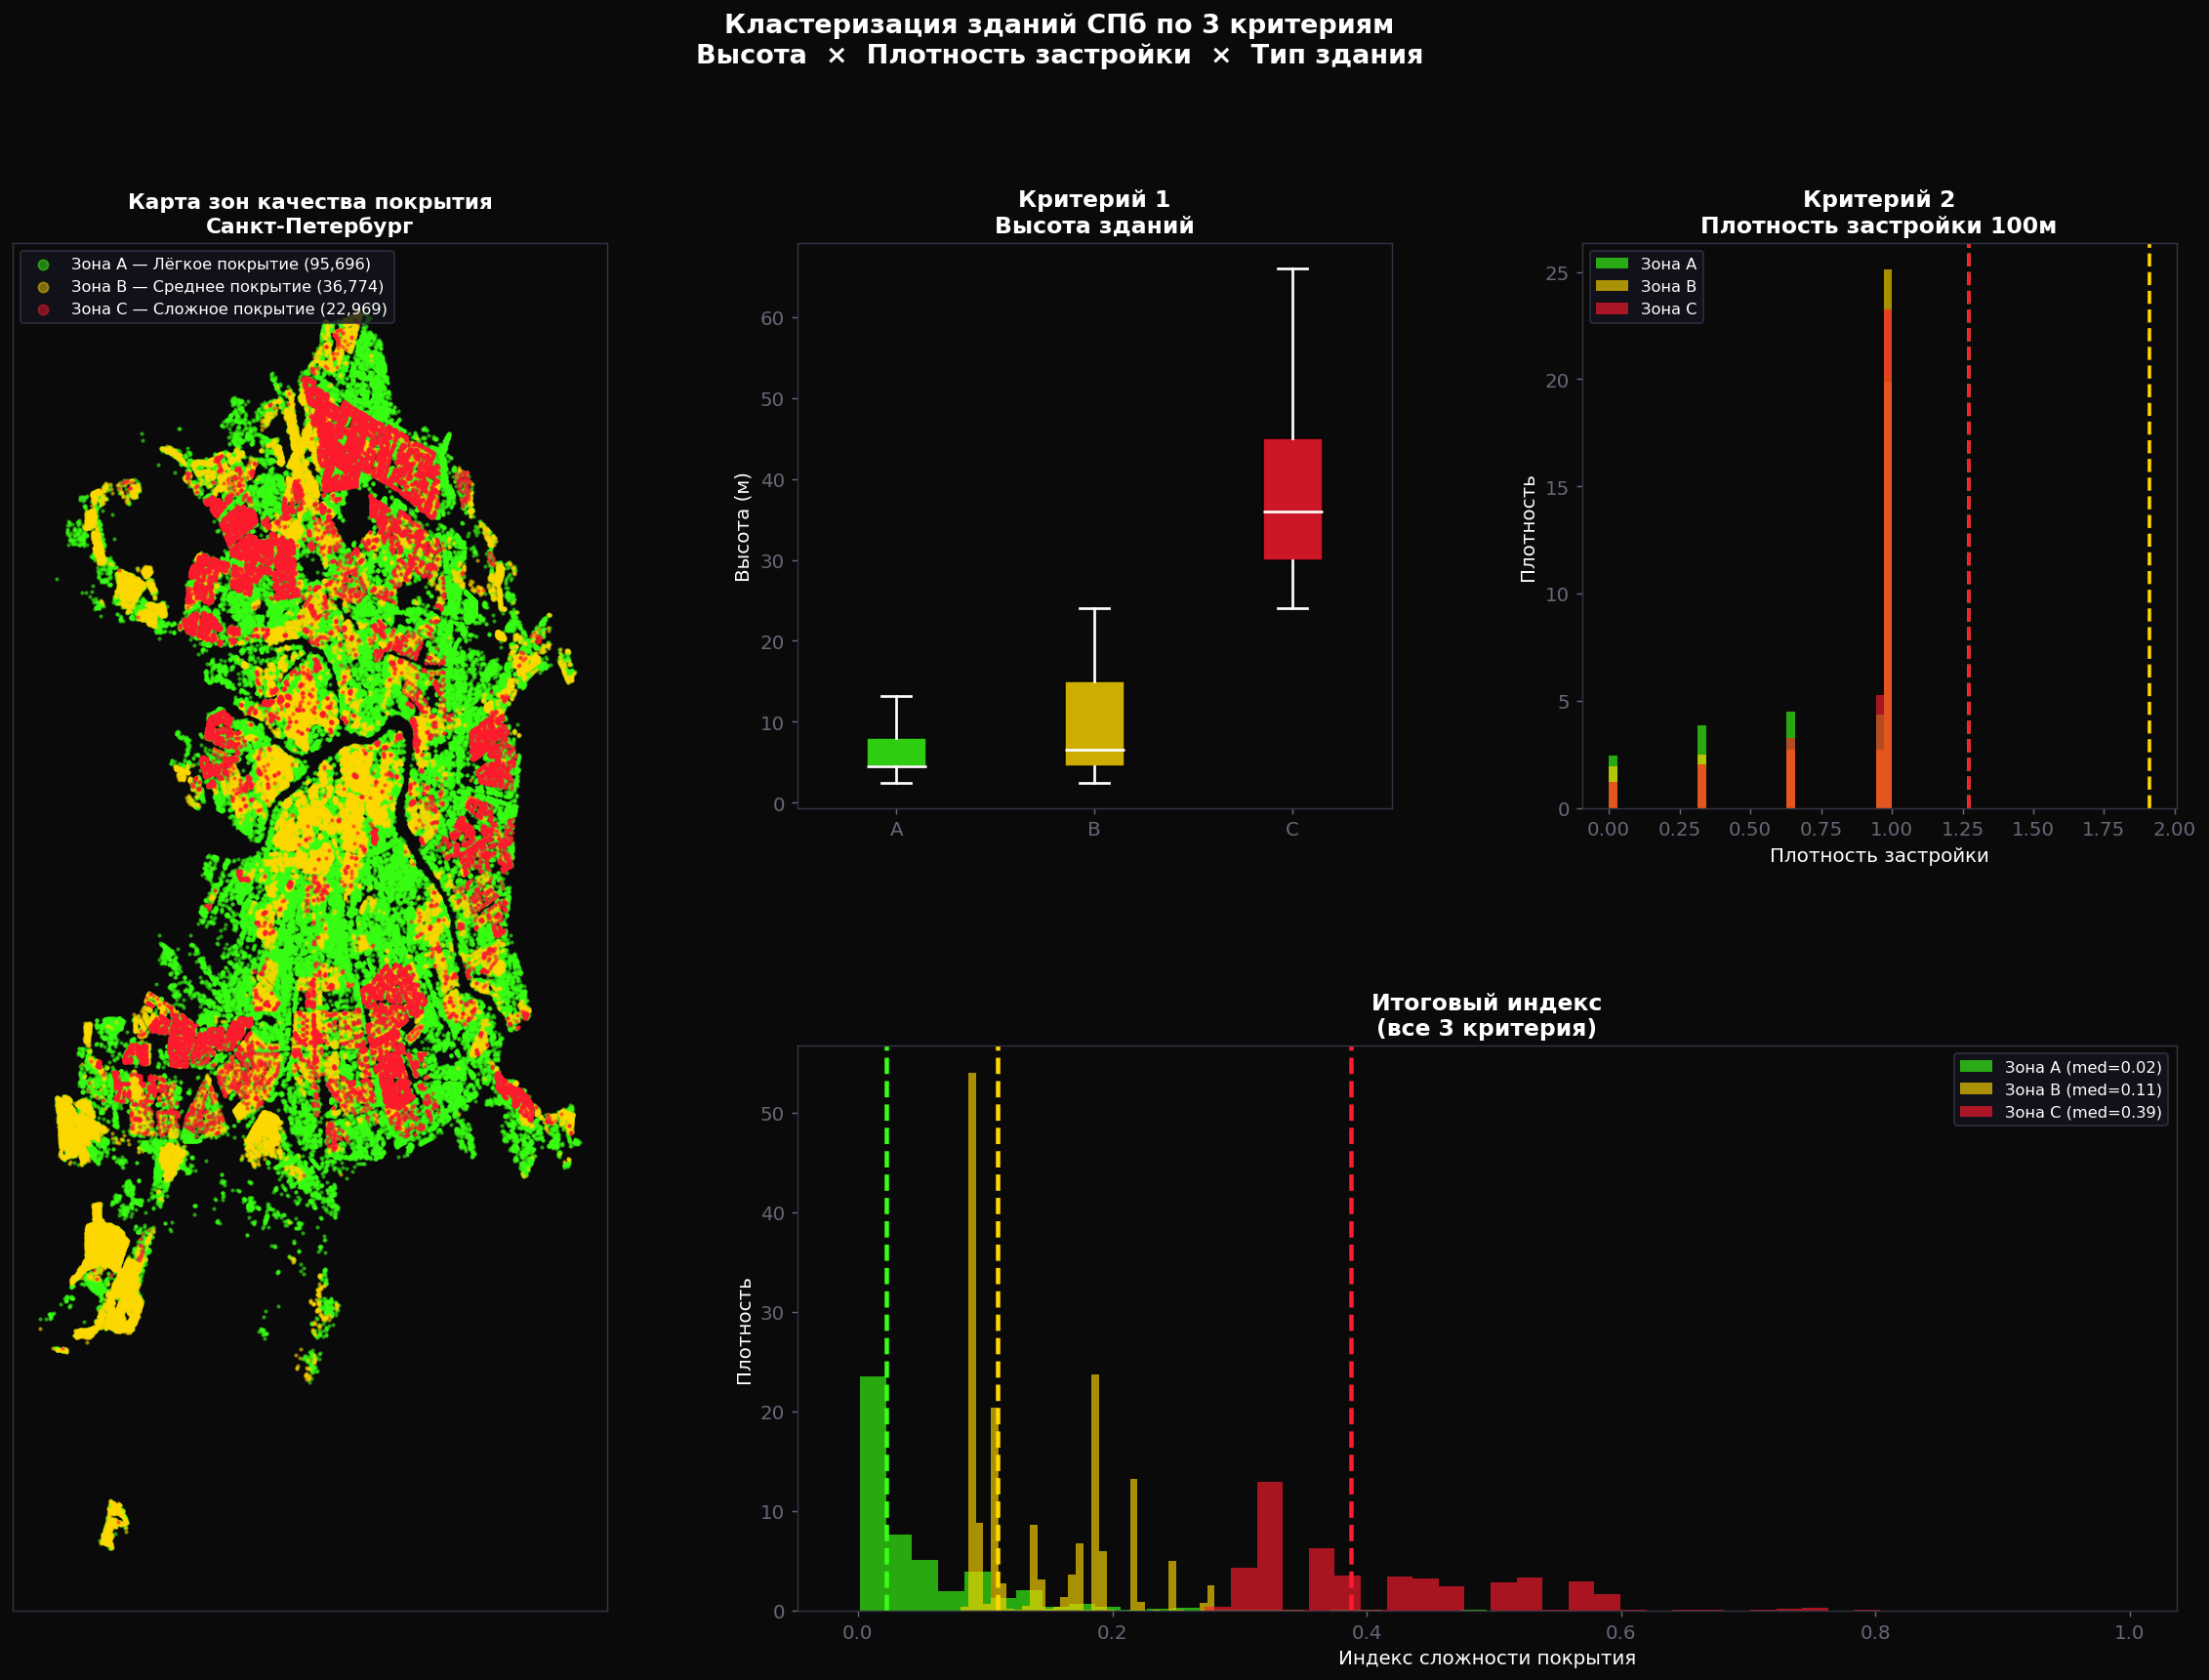

Сохранено: mts_3zone_clustering.png


In [21]:
# Визуализация — финальный дашборд
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0A0A0A')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)
fig.suptitle(
    'Кластеризация зданий СПб по 3 критериям\n'
    'Высота  ×  Плотность застройки  ×  Тип здания',
    fontsize=15, color='white', fontweight='bold', y=1.01
)

# Карта зон
ax1 = fig.add_subplot(gs[:, 0])
ax1.set_facecolor('#0A0A0A')
for zone in ZONE_ORDER:
    sub = filled[filled['coverage_zone'] == zone]
    if len(sub):
        ax1.scatter(sub['feat_x_coord'], sub['feat_y_coord'],
                    c=COLORS[zone], s=2, alpha=0.45,
                    label=f'{zone} ({len(sub):,})')
ax1.legend(fontsize=9, markerscale=4, facecolor='#14141E',
           edgecolor='#333344', labelcolor='white', loc='upper left')
ax1.set_title('Карта зон качества покрытия\nСанкт-Петербург',
              color='white', fontweight='bold', fontsize=12)
ax1.set_xticks([]); ax1.set_yticks([])
for sp in ax1.spines.values(): sp.set_edgecolor('#333344')

# Критерий 1: Высота
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#0A0A0A')
data_bp = [filled[filled['coverage_zone'] == z]['final_height_m']
           .clip(0, 80).dropna() for z in ZONE_ORDER]
bp = ax2.boxplot(data_bp, labels=['A', 'B', 'C'],
                 patch_artist=True, notch=False, showfliers=False)
for patch, zone in zip(bp['boxes'], ZONE_ORDER):
    patch.set_facecolor(COLORS[zone]); patch.set_alpha(0.8)
for el in ['whiskers', 'caps', 'medians']:
    for line in bp[el]: line.set_color('white'); line.set_linewidth(1.5)
ax2.set_ylabel('Высота (м)', color='white')
ax2.set_title('Критерий 1\nВысота зданий', color='white', fontweight='bold')
ax2.tick_params(colors='#666677')

# Критерий 2: Плотность
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#0A0A0A')
for zone in ZONE_ORDER:
    data = filled[filled['coverage_zone'] == zone]['feat_density_100m'].dropna()
    ax3.hist(data.clip(0, 1), bins=35, color=COLORS[zone],
             alpha=0.65, density=True, label=zone.split('—')[0].strip())
    ax3.axvline(data.median(), color=COLORS[zone], linestyle='--', linewidth=2)
ax3.set_xlabel('Плотность застройки', color='white')
ax3.set_ylabel('Плотность', color='white')
ax3.set_title('Критерий 2\nПлотность застройки 100м', color='white', fontweight='bold')
ax3.legend(fontsize=9, facecolor='#14141E', edgecolor='#333344', labelcolor='white')
ax3.tick_params(colors='#666677')

# Итоговый индекс
ax4 = fig.add_subplot(gs[1, 1:])
ax4.set_facecolor('#0A0A0A')
for zone in ZONE_ORDER:
    data = filled[filled['coverage_zone'] == zone]['coverage_difficulty'].dropna()
    ax4.hist(data, bins=35, color=COLORS[zone], alpha=0.65, density=True,
             label=f"{zone.split('—')[0].strip()} (med={data.median():.2f})")
    ax4.axvline(data.median(), color=COLORS[zone], linestyle='--', linewidth=2.5)
ax4.set_xlabel('Индекс сложности покрытия', color='white')
ax4.set_ylabel('Плотность', color='white')
ax4.set_title('Итоговый индекс\n(все 3 критерия)', color='white', fontweight='bold')
ax4.legend(fontsize=9, facecolor='#14141E', edgecolor='#333344', labelcolor='white')
ax4.tick_params(colors='#666677')

plt.tight_layout()
plt.savefig('mts_3zone_clustering.png', dpi=150,
            bbox_inches='tight', facecolor='#0A0A0A')
plt.show()
print('Сохранено: mts_3zone_clustering.png')

### Выводы: зоны качества покрытия

**Трёхкритериальная кластеризация** даёт МТС операционный инструмент для дифференцированного планирования сети:

**🟢 Зона A — Лёгкое покрытие**  
Малоэтажная разреженная застройка — преимущественно хозпостройки и частный сектор
Стратегия МТС: 1 мощная вышка покрывает большой радиус, экономия бюджета

**🟡 Зона B — Среднее покрытие**  
Смешанная застройка средней плотности. Требует 2–3 станции с направленными антеннами

**🔴 Зона C — Сложное покрытие**  
Плотная высокая застройка — преимущественно жилые многоэтажки и комплексы зданий  
Стратегия МТС: плотная сеть малых сот, тщательная калибровка каждой станции

**Почему это лучше стандартного подхода:**  
Одно только здание высотой 15м в разреженном районе (Зона A) даёт иную картину покрытия  
чем то же здание в плотном квартале (Зона C) — наш индекс учитывает оба фактора одновременно

In [22]:
import json
import ast

# Сохранение данных для визуализации в Kepler

# Парсим геометрию из WKT в GeoJSON
from shapely import wkt as swkt
from shapely.geometry import mapping

# Цвета зон для Kepler
zone_colors = {
    'Зона A — Лёгкое покрытие':  '#39FF14',
    'Зона B — Среднее покрытие':  '#FFD700',
    'Зона C — Сложное покрытие':  '#FF1A2E',
}

features = []
errors = 0

for _, row in filled.iterrows():
    try:
        geom = swkt.loads(str(row['geometry_wkt']))
        feature = {
            "type": "Feature",
            "geometry": mapping(geom),
            "properties": {
                "id":               str(row.get('id', '')),
                "coverage_zone":    row.get('coverage_zone', ''),
                "final_height_m":   float(row.get('final_height_m', 0) or 0),
                "primary_type":     str(row.get('primary_type', '')),
                "height_source":    str(row.get('height_source', '')),
                "difficulty_index": float(row.get('coverage_difficulty', 0) or 0),
                "zone_color":       zone_colors.get(row.get('coverage_zone', ''), '#FFFFFF'),
                "area_sq_m":        float(row.get('area_sq_m', 0) or 0),
            }
        }
        features.append(feature)
    except Exception:
        errors += 1
        continue

geojson = {
    "type": "FeatureCollection",
    "features": features
}

output_path = 'spb_buildings_zones.geojson'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(geojson, f, ensure_ascii=False)

print(f'Сохранено: {output_path}')
print(f'Объектов:  {len(features):,}')
print(f'Ошибок:    {errors}')
print(f'\nРаспределение по зонам:')
for zone, cnt in filled['coverage_zone'].value_counts().items():
    print(f'  {zone}: {cnt:,}')

Сохранено: spb_buildings_zones.geojson
Объектов:  155,439
Ошибок:    0

Распределение по зонам:
  Зона A — Лёгкое покрытие: 95,696
  Зона B — Среднее покрытие: 36,774
  Зона C — Сложное покрытие: 22,969


---
# Раздел 9. Итоги и рекомендации

Финальная сводка всех инсайтов с бизнес-интерпретацией

findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Font family 'Arial Black' not found.
findfont: Fon

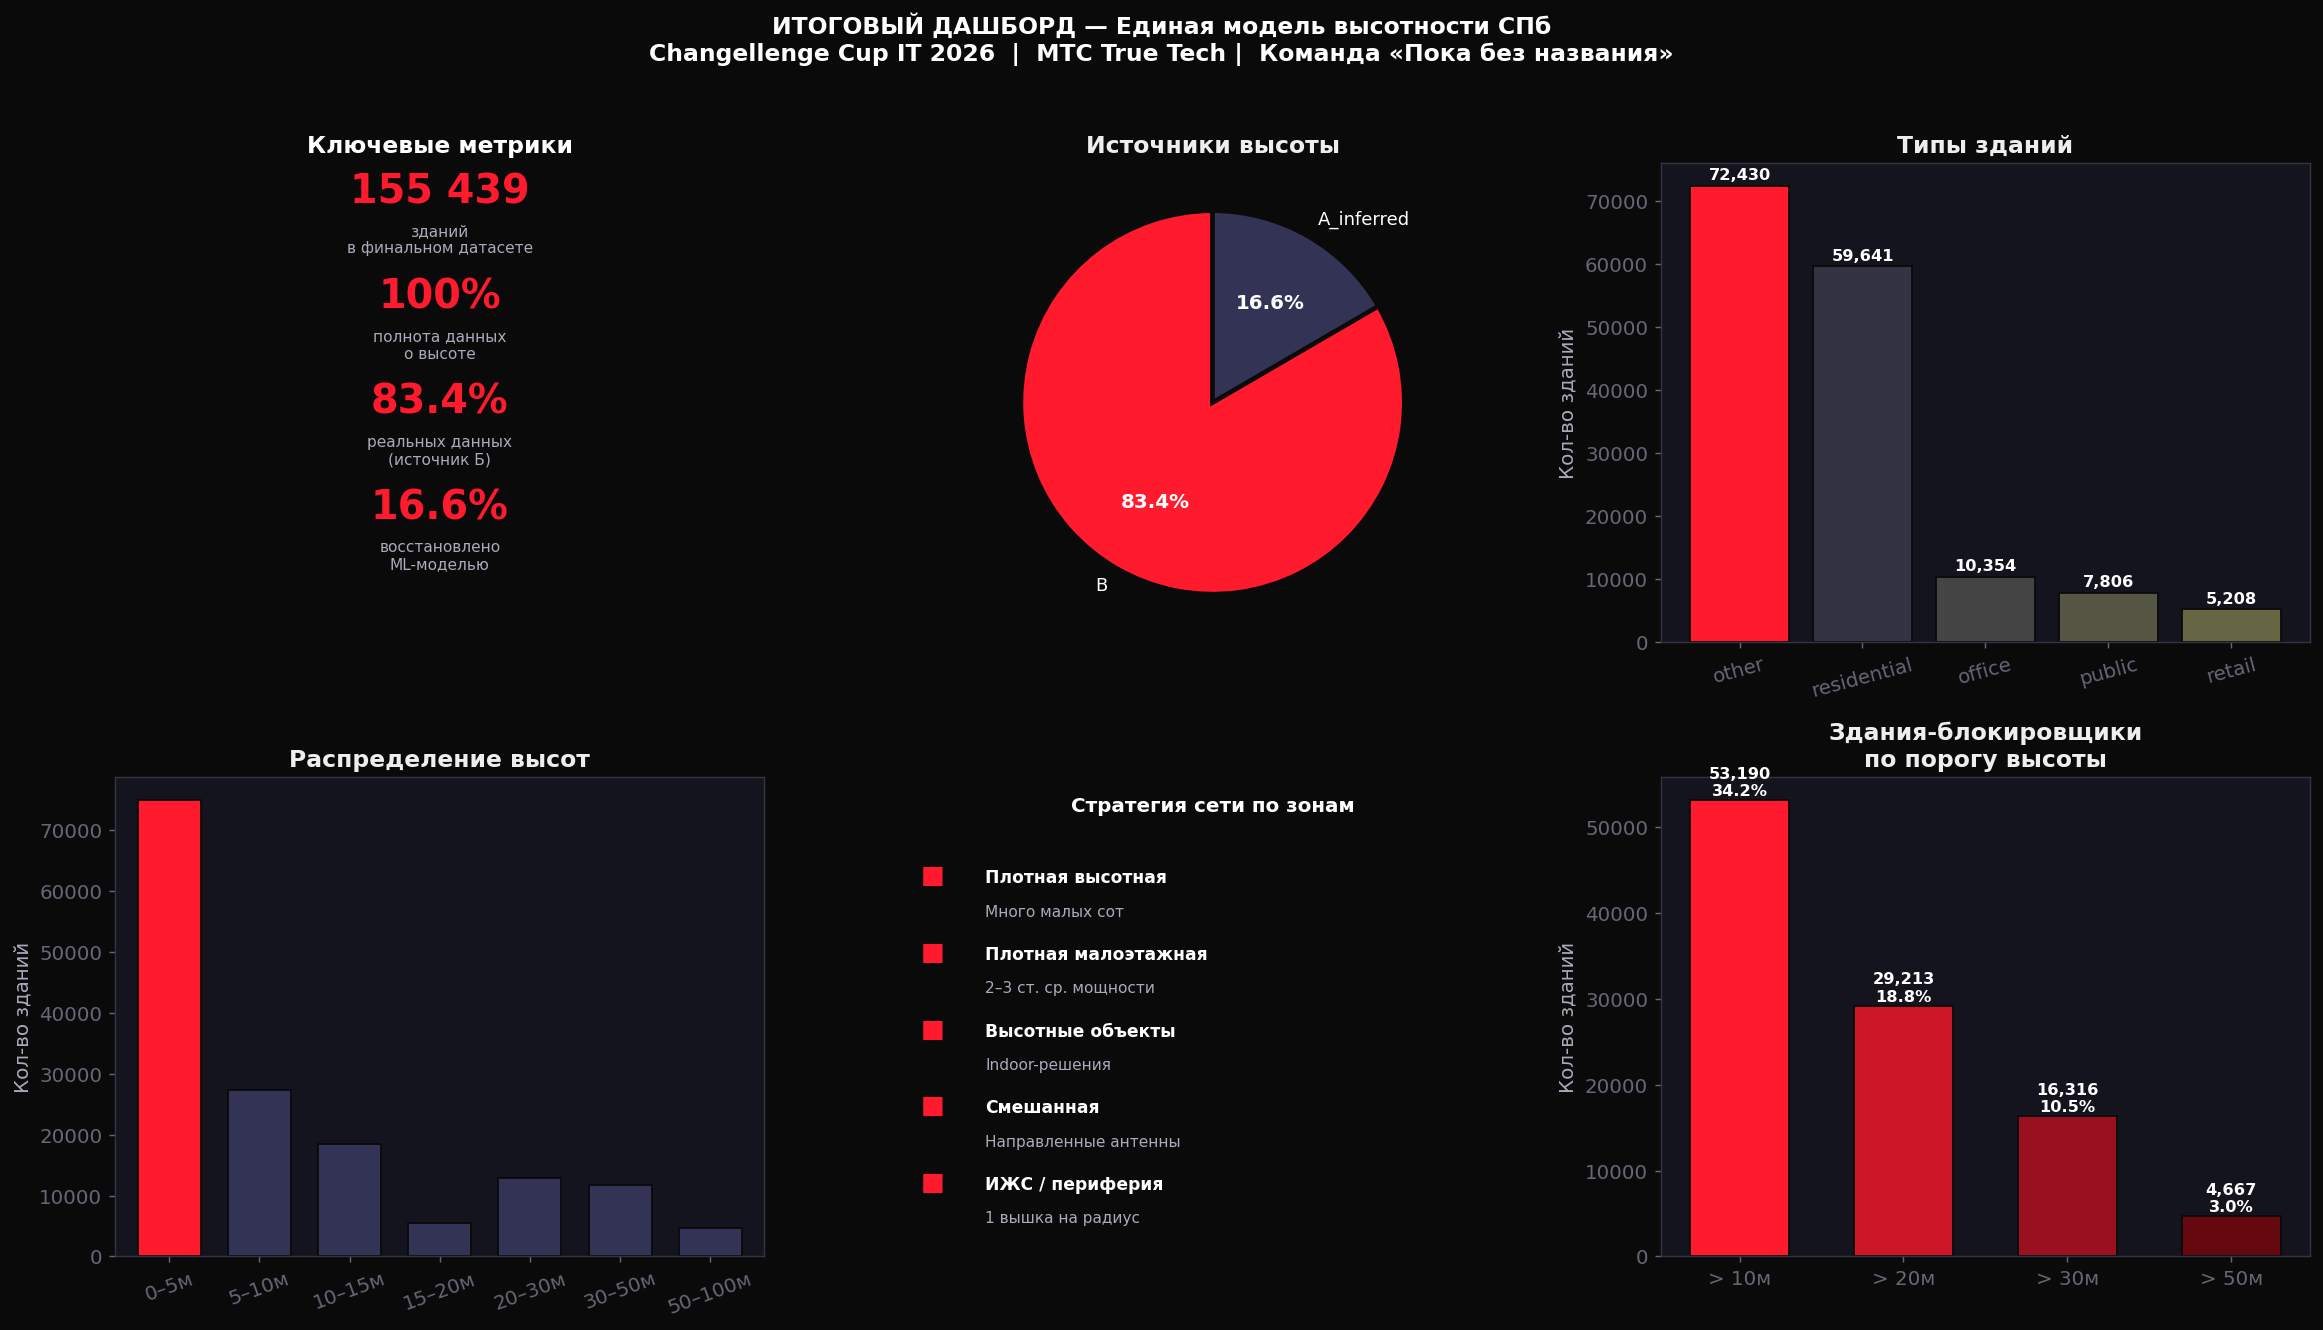

Дашборд сохранён: mts_dashboard.png


In [23]:
# Финальный дашборд
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0A0A0A')
fig.suptitle('ИТОГОВЫЙ ДАШБОРД — Единая модель высотности СПб\nChangellenge Cup IT 2026  |  МТС True Tech |  Команда «Пока без названия»',
             fontsize=13, color=WHITE, fontweight='bold', y=1.02)

# Ключевые метрики — текстовый блок
ax = axes[0, 0]
ax.set_facecolor('#0A0A0A')
ax.axis('off')
metrics = [
    ('155 439',  'зданий\nв финальном датасете', 0.88),
    ('100%',     'полнота данных\nо высоте', 0.66),
    ('83.4%',    'реальных данных\n(источник Б)', 0.44),
    ('16.6%',    'восстановлено\nML-моделью', 0.22),
]
for num, lbl, y_pos in metrics:
    ax.text(0.5, y_pos+0.06, num, transform=ax.transAxes,
            fontsize=22, color=RED, fontweight='bold',
            ha='center', va='center', fontfamily='Arial Black')
    ax.text(0.5, y_pos-0.04, lbl, transform=ax.transAxes,
            fontsize=8.5, color=GREY, ha='center', va='center')
ax.set_title('Ключевые метрики', color=WHITE)

# Источники высоты (пирог)
ax = axes[0, 1]
if 'height_source' in filled.columns:
    src = filled['height_source'].value_counts()
    wedges, texts, autotexts = ax.pie(
        src.values, labels=src.index,
        colors=[RED, '#333355'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': '#0A0A0A', 'linewidth': 2.5}
    )
    for t in texts: t.set_color(WHITE); t.set_fontsize(10)
    for t in autotexts: t.set_color(WHITE); t.set_fontweight('bold')
ax.set_title('Источники высоты')

# Типы зданий
ax = axes[0, 2]
if 'feat_building_type' in filled.columns:
    bt = filled['feat_building_type'].value_counts()
    colors_bt = [RED if i == 0 else f'#{0x22+i*0x11:02x}{0x22+i*0x11:02x}44' for i in range(len(bt))]
    ax.bar(bt.index, bt.values, color=colors_bt, edgecolor='#0A0A0A')
    for i, (idx, val) in enumerate(bt.items()):
        ax.text(i, val + 500, f'{val:,}', ha='center', va='bottom',
                color=WHITE, fontsize=9, fontweight='bold')
    ax.set_ylabel('Кол-во зданий')
    ax.set_title('Типы зданий')
    ax.tick_params(axis='x', rotation=15)

# Распределение высот
ax = axes[1, 0]
bin_counts.plot(kind='bar', ax=ax, color=[RED if i == 0 else '#333355'
                for i in range(len(bin_counts))], edgecolor='#0A0A0A', width=0.7)
ax.set_xlabel('')
ax.set_ylabel('Кол-во зданий')
ax.set_title('Распределение высот')
ax.tick_params(axis='x', rotation=20)

# Зоны
ax = axes[1, 1]
ax.axis('off')
ax.set_facecolor('#0A0A0A')
zones_data = [
    ('■', 'Плотная высотная',    'Много малых сот'),
    ('■', 'Плотная малоэтажная', '2–3 ст. ср. мощности'),
    ('■', 'Высотные объекты',    'Indoor-решения'),
    ('■', 'Смешанная',           'Направленные антенны'),
    ('■', 'ИЖС / периферия',     '1 вышка на радиус'),
]
ax.text(0.5, 0.96, 'Стратегия сети по зонам',
        transform=ax.transAxes, fontsize=11, color=WHITE,
        fontweight='bold', ha='center', va='top')
for i, (dot, name, rec) in enumerate(zones_data):
    y = 0.78 - i*0.16
    ax.text(0.05, y, dot, transform=ax.transAxes, fontsize=14, color=RED)
    ax.text(0.15, y, name, transform=ax.transAxes, fontsize=9.5, color=WHITE, fontweight='bold')
    ax.text(0.15, y-0.07, rec, transform=ax.transAxes, fontsize=8.5, color=GREY)

# Блокировщики
ax = axes[1, 2]
bl_data = {'> 10м': (h>10).sum(), '> 20м': (h>20).sum(),
           '> 30м': (h>30).sum(), '> 50м': (h>50).sum()}
shades = [RED, '#CC1525', '#991020', '#66080F']
bars_bl = ax.bar(bl_data.keys(), bl_data.values(), color=shades, edgecolor='#0A0A0A', width=0.6)
for bar, val in zip(bars_bl, bl_data.values()):
    pct = val / len(filled) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n{pct:.1f}%', ha='center', va='bottom',
            color=WHITE, fontsize=9, fontweight='bold')
ax.set_ylabel('Кол-во зданий')
ax.set_title('Здания-блокировщики\nпо порогу высоты')

plt.tight_layout()
plt.savefig('mts_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0A0A0A', edgecolor='none')
plt.show()
print('Дашборд сохранён: mts_dashboard.png')